In [ ]:
# Удаление пропущенных значений
df = df.dropna(subset=['ds', 'y'])
df = df.sort_values('ds').reset_index(drop=True)

data_train.tail(-5) и head

_ = если два графика отображаются (в ВС коде один)
_ = plot_acf(original_df.target, lags=60)
plt.grid()

In [ ]:
print(model.summary())

In [ ]:
print(model.params()) ????

Тесты Дики-Фуллера (ADF) и KPSS

Полагаться только на визуальный анализ рискованно — иногда тренд или сезонность могут быть не так очевидны. Чтобы принять объективное решение, используют статистические тесты. Самый популярный из них — расширенный тест Дики-Фуллера (Augmented Dickey-Fuller Test, ADF). 

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import tree
import math #### все функции
from sklearn.tree import DecisionTreeClassifier
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_curve
from IPython.display import display, HTML
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier

from sympy import *

import mpl_toolkits.mplot3d as p3
import random
import time


from functools import partial
#from ipywidgets import interact, RadioButtons, IntSlider, FloatSlider, Dropdown, BoundedFloatText
from numpy.linalg import norm

from scipy import sparse

random.seed(42) # начальное состояние генератора случайных чисел, чтобы можно было воспроизводить результаты.

#!unzip «путь_до_архива»
#Всё извлечётся в память Colab.

In [2]:
# plotting
import scipy.stats as sps
import matplotlib.pyplot as plt
import seaborn as sns

# не ЕTNA модели Prophet, TBATS, SARIMAX — модели для предсказания временных рядов
import statsmodels

# metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

# models
from tbats import TBATS
from prophet import Prophet
from pmdarima import auto_arima

# make plots bigger
from pylab import rcParams
rcParams['figure.figsize'] = 15, 7

In [3]:
import pandas as pd
import numpy as np

from etna.datasets.tsdataset import TSDataset

# модели
from etna.models import (NaiveModel, 
                         MovingAverageModel, 
                         SeasonalMovingAverageModel,
                         HoltWintersModel)

from etna.models import ProphetModel
from etna.models import CatBoostMultiSegmentModel


from etna.pipeline import Pipeline


from etna.metrics import MAE, MSE, SMAPE, MAPE

# аналитика
from etna.analysis import plot_forecast
from etna.analysis import plot_backtest
from etna.analysis import plot_feature_relevance
from etna.analysis import ModelRelevanceTable
from statsmodels.graphics.tsaplots import plot_acf

# трансформации
from etna.transforms import MeanTransform, LagTransform
from sklearn.ensemble import RandomForestRegressor


%config InlineBackend.figure_format = 'retina'

import warnings
warnings.filterwarnings('ignore')

In [4]:
# загружаем набор о ежемесячных продажах вина в Австралии
original_df = pd.read_csv(
    '/workspaces/pyt_begin/data_data/monthly_australian_wine_sales.csv'
    )
original_df.head()

,month,sales
0,1980-01-01,15136
1,1980-02-01,16733
2,1980-03-01,20016
3,1980-04-01,17708
4,1980-05-01,18019


In [52]:
original_df,

(     timestamp   target segment
 0   1980-01-01  15136.0    main
 1   1980-02-01  16733.0    main
 2   1980-03-01  20016.0    main
 3   1980-04-01  17708.0    main
 4   1980-05-01  18019.0    main
 ..         ...      ...     ...
 171 1994-04-01  26323.0    main
 172 1994-05-01  23779.0    main
 173 1994-06-01  27549.0    main
 174 1994-07-01  29660.0    main
 175 1994-08-01  23356.0    main
 
 [176 rows x 3 columns],)

In [5]:
# задаем обязательные столбцы target, timestamp и segment

original_df['timestamp'] = pd.to_datetime(original_df['month'])
original_df['target'] = original_df['sales']

original_df.drop(columns=['month', 'sales'], inplace=True)
original_df['segment'] = 'main'
original_df.head()

,timestamp,target,segment
0,1980-01-01,15136,main
1,1980-02-01,16733,main
2,1980-03-01,20016,main
3,1980-04-01,17708,main
4,1980-05-01,18019,main


In [6]:
df = TSDataset.to_dataset(original_df)
ts = TSDataset(df, freq='MS')
ts.head()

segment,main
feature,target
timestamp,
1980-01-01,15136.0
1980-02-01,16733.0
1980-03-01,20016.0
1980-04-01,17708.0
1980-05-01,18019.0


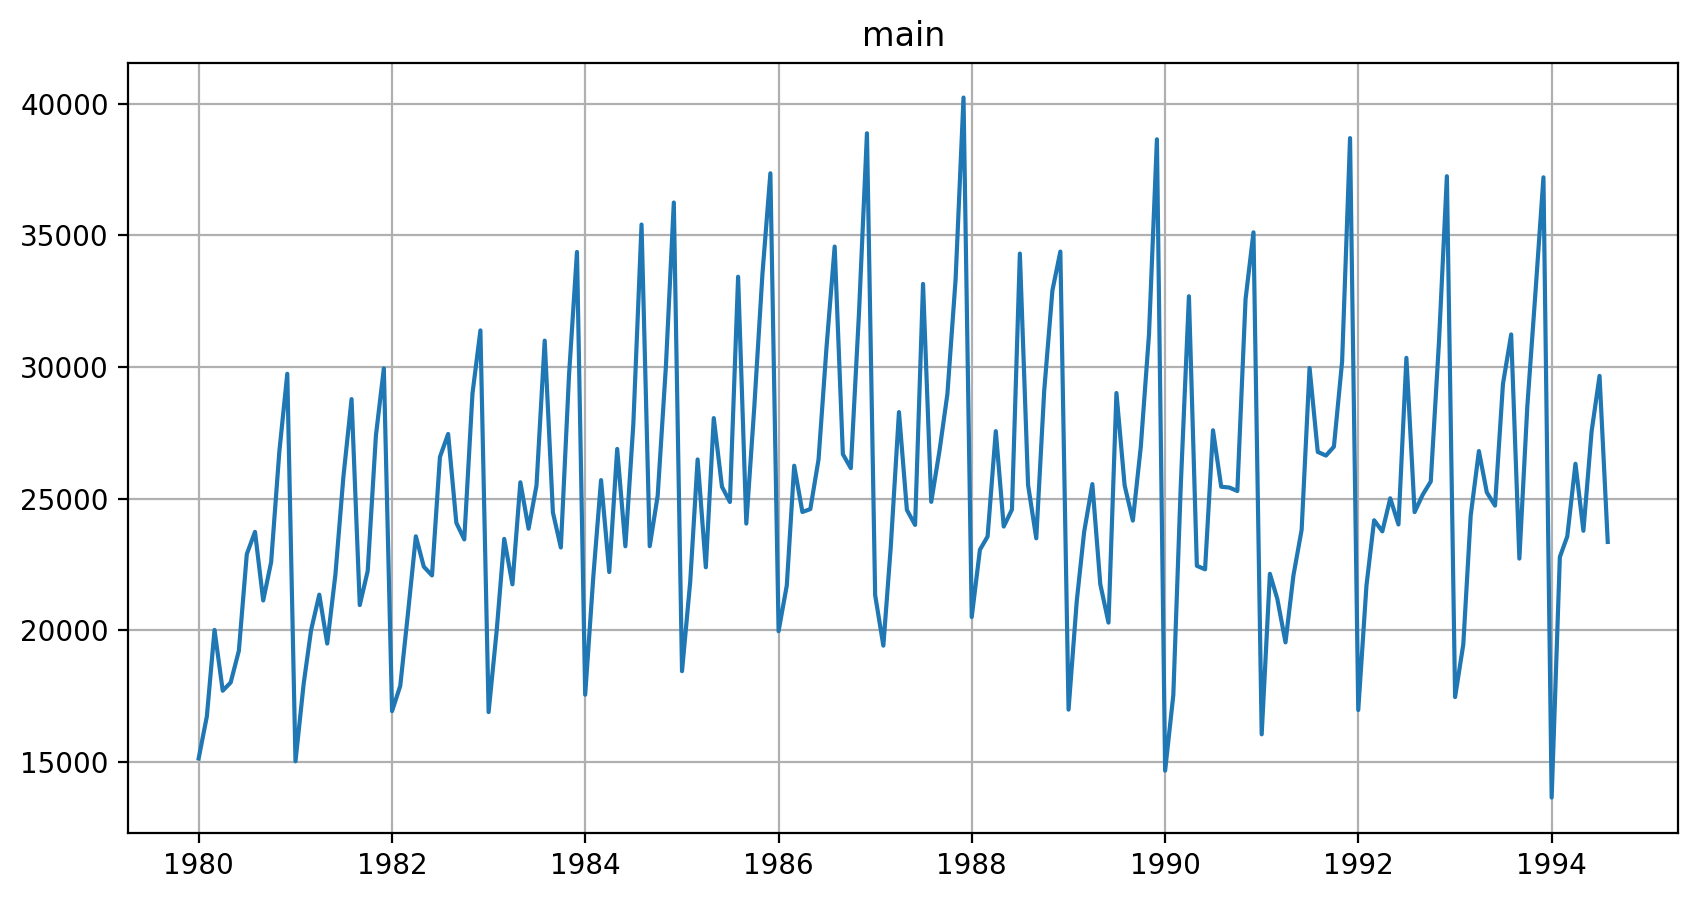

In [7]:
ts.plot()

In [8]:
# разбиваем набор на обучающую и тестовую выборки с учетом временной структуры
train_ts, test_ts = ts.train_test_split(train_start='1980-01-01',
                                        train_end='1993-12-01',
                                        test_start='1994-01-01',
                                        test_end='1994-08-01')
HORIZON = 8

In [25]:
# Модель наивного прогноза
train_ts

segment,main
feature,target
timestamp,
1980-01-01,15136.0
1980-02-01,16733.0
1980-03-01,20016.0
1980-04-01,17708.0
1980-05-01,18019.0
...,...
1993-08-01,31234.0
1993-09-01,22724.0


In [117]:
# лаг 1
HORIZON = 8
model = NaiveModel(lag=1)
model.fit(train_ts)

future_ts = train_ts.make_future(future_steps=HORIZON, 
                                 tail_steps=model.context_size)
future_ts

segment,main
feature,target
timestamp,
1993-12-01,37198.0
1994-01-01,NaN
1994-02-01,NaN
1994-03-01,NaN
1994-04-01,NaN
1994-05-01,NaN
1994-06-01,NaN
1994-07-01,NaN


In [10]:
forecast_ts = model.forecast(future_ts, 
                             prediction_size=HORIZON)
forecast_ts

segment,main
feature,target
timestamp,
1994-01-01,37198.0
1994-02-01,37198.0
1994-03-01,37198.0
1994-04-01,37198.0
1994-05-01,37198.0
1994-06-01,37198.0
1994-07-01,37198.0
1994-08-01,37198.0


In [9]:
# с лагом 3
model = NaiveModel(lag=3)
model.fit(train_ts)
future_ts = train_ts.make_future(future_steps=HORIZON, 
                                 tail_steps=model.context_size)
forecast_ts = model.forecast(future_ts, 
                             prediction_size=HORIZON)
forecast_ts

segment,main
feature,target
timestamp,
1994-01-01,28496.0
1994-02-01,32857.0
1994-03-01,37198.0
1994-04-01,28496.0
1994-05-01,32857.0
1994-06-01,37198.0
1994-07-01,28496.0
1994-08-01,32857.0


In [118]:
model = NaiveModel(lag=12)
model.fit(train_ts)
future_ts = train_ts.make_future(future_steps=HORIZON, 
                                 tail_steps=model.context_size)
forecast_ts = model.forecast(future_ts, 
                             prediction_size=HORIZON)
forecast_ts

segment,main
feature,target
timestamp,
1994-01-01,17466.0
1994-02-01,19463.0
1994-03-01,24352.0
1994-04-01,26805.0
1994-05-01,25236.0
1994-06-01,24735.0
1994-07-01,29356.0
1994-08-01,31234.0


In [10]:
#!!!!!!!!!!

smape = SMAPE()
smape(y_true=test_ts, y_pred=forecast_ts)

{'main': np.float64(32.389301909102166)}

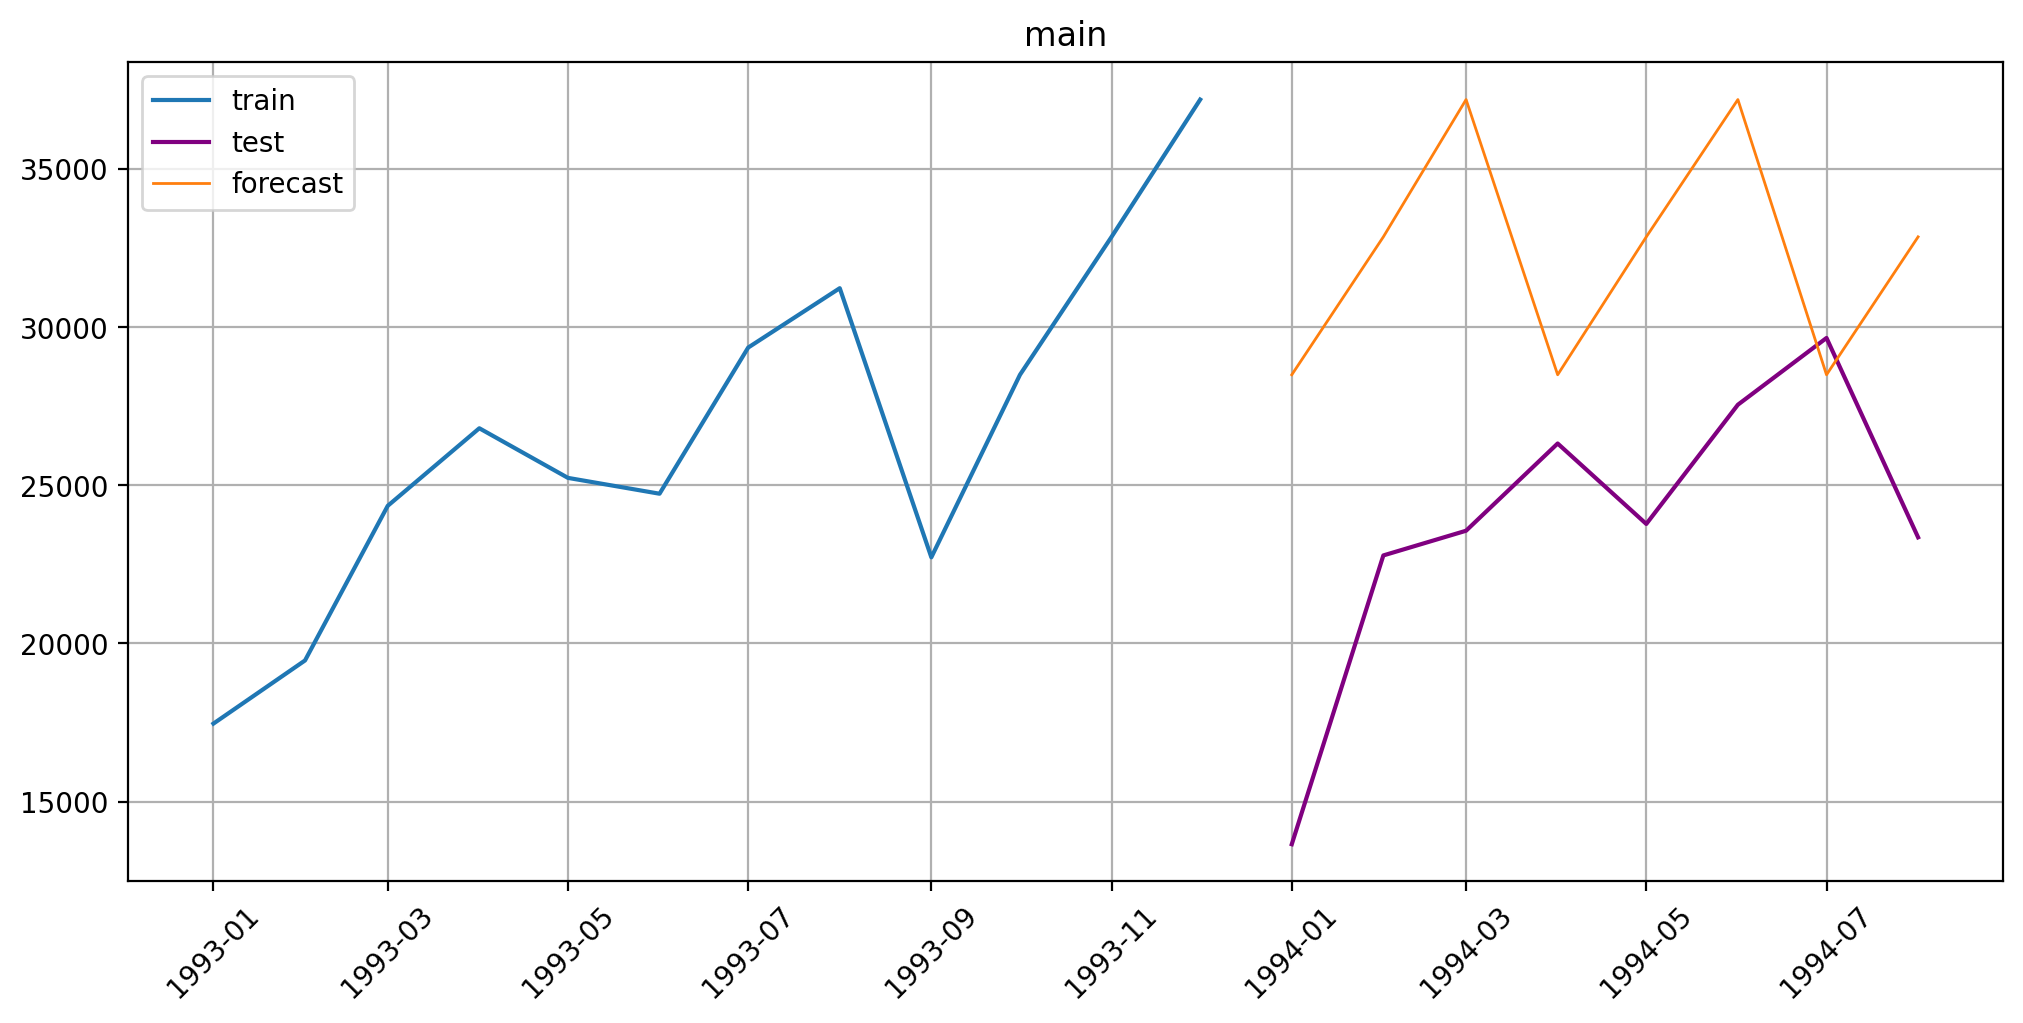

In [11]:
plot_forecast(forecast_ts, test_ts, train_ts, n_train_samples=12)

"Модель скользящего среднего", двигает окно

In [34]:
model = MovingAverageModel(window=5)

model.fit(train_ts)
future_ts = train_ts.make_future(future_steps=HORIZON,
                                 tail_steps=model.context_size)
forecast_ts = model.forecast(future_ts, 
                             prediction_size=HORIZON)
forecast_ts

segment,main
feature,target
timestamp,
1994-01-01,30501.800000
1994-02-01,30355.360000
1994-03-01,31881.632000
1994-04-01,32558.758400
1994-05-01,32499.110080
1994-06-01,31559.332096
1994-07-01,31770.838515
1994-08-01,32053.934218


In [49]:
smape(y_true=test_ts, y_pred=forecast_ts)

{'main': np.float64(15.402966210553313)}

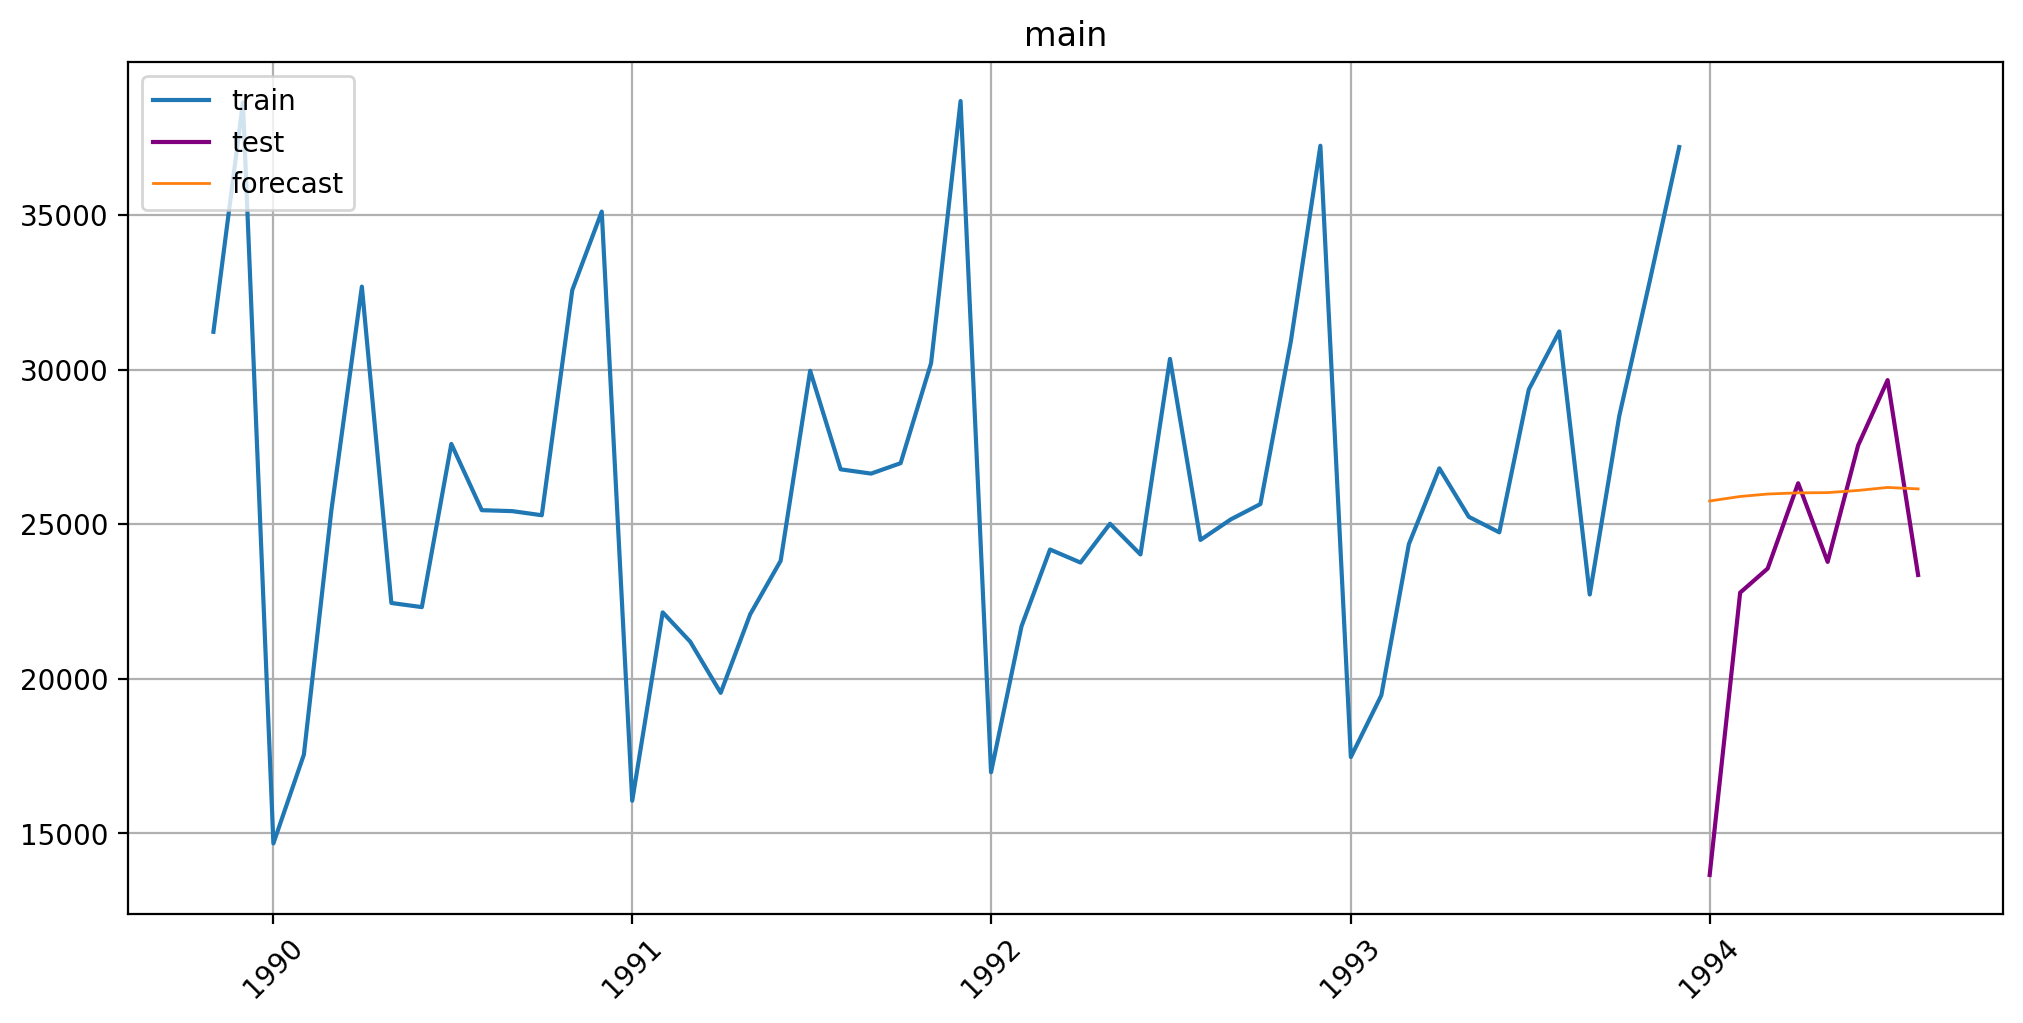

In [50]:
plot_forecast(forecast_ts, test_ts, train_ts, n_train_samples=50)

In [37]:
# окно 12 хуже чем 5
model = MovingAverageModel(window=12)

model.fit(train_ts)
future_ts = train_ts.make_future(future_steps=HORIZON,
                                 tail_steps=model.context_size)
forecast_ts = model.forecast(future_ts, 
                             prediction_size=HORIZON)

In [ ]:
# окно 60.  линия прогноза на тесте, без точек перехода нужна сезонность в модели
model = MovingAverageModel(window=60)

model.fit(train_ts)
future_ts = train_ts.make_future(future_steps=HORIZON,
                                 tail_steps=model.context_size)
forecast_ts = model.forecast(future_ts, 
                             prediction_size=HORIZON)

!!!!!   Модель сезонного скользящего среднего

In [12]:
model = SeasonalMovingAverageModel(window=5, seasonality=12)
model.fit(train_ts)
future_ts = train_ts.make_future(future_steps=HORIZON,
                                 tail_steps=model.context_size)
                                 
forecast_ts = model.forecast(future_ts, 
                             prediction_size=HORIZON)
forecast_ts

segment,main
feature,target
timestamp,
1994-01-01,16431.0
1994-02-01,20391.6
1994-03-01,23784.4
1994-04-01,25668.0
1994-05-01,23306.8
1994-06-01,23036.0
1994-07-01,29253.2
1994-08-01,26689.2


In [41]:
future_ts

segment,main
feature,target
timestamp,
1994-01-01,16431.0
1994-02-01,20391.6
1994-03-01,23784.4
1994-04-01,25668.0
1994-05-01,23306.8
1994-06-01,23036.0
1994-07-01,29253.2
1994-08-01,26689.2


In [13]:
smape(y_true=test_ts, y_pred=forecast_ts)

{'main': np.float64(8.444354755762415)}

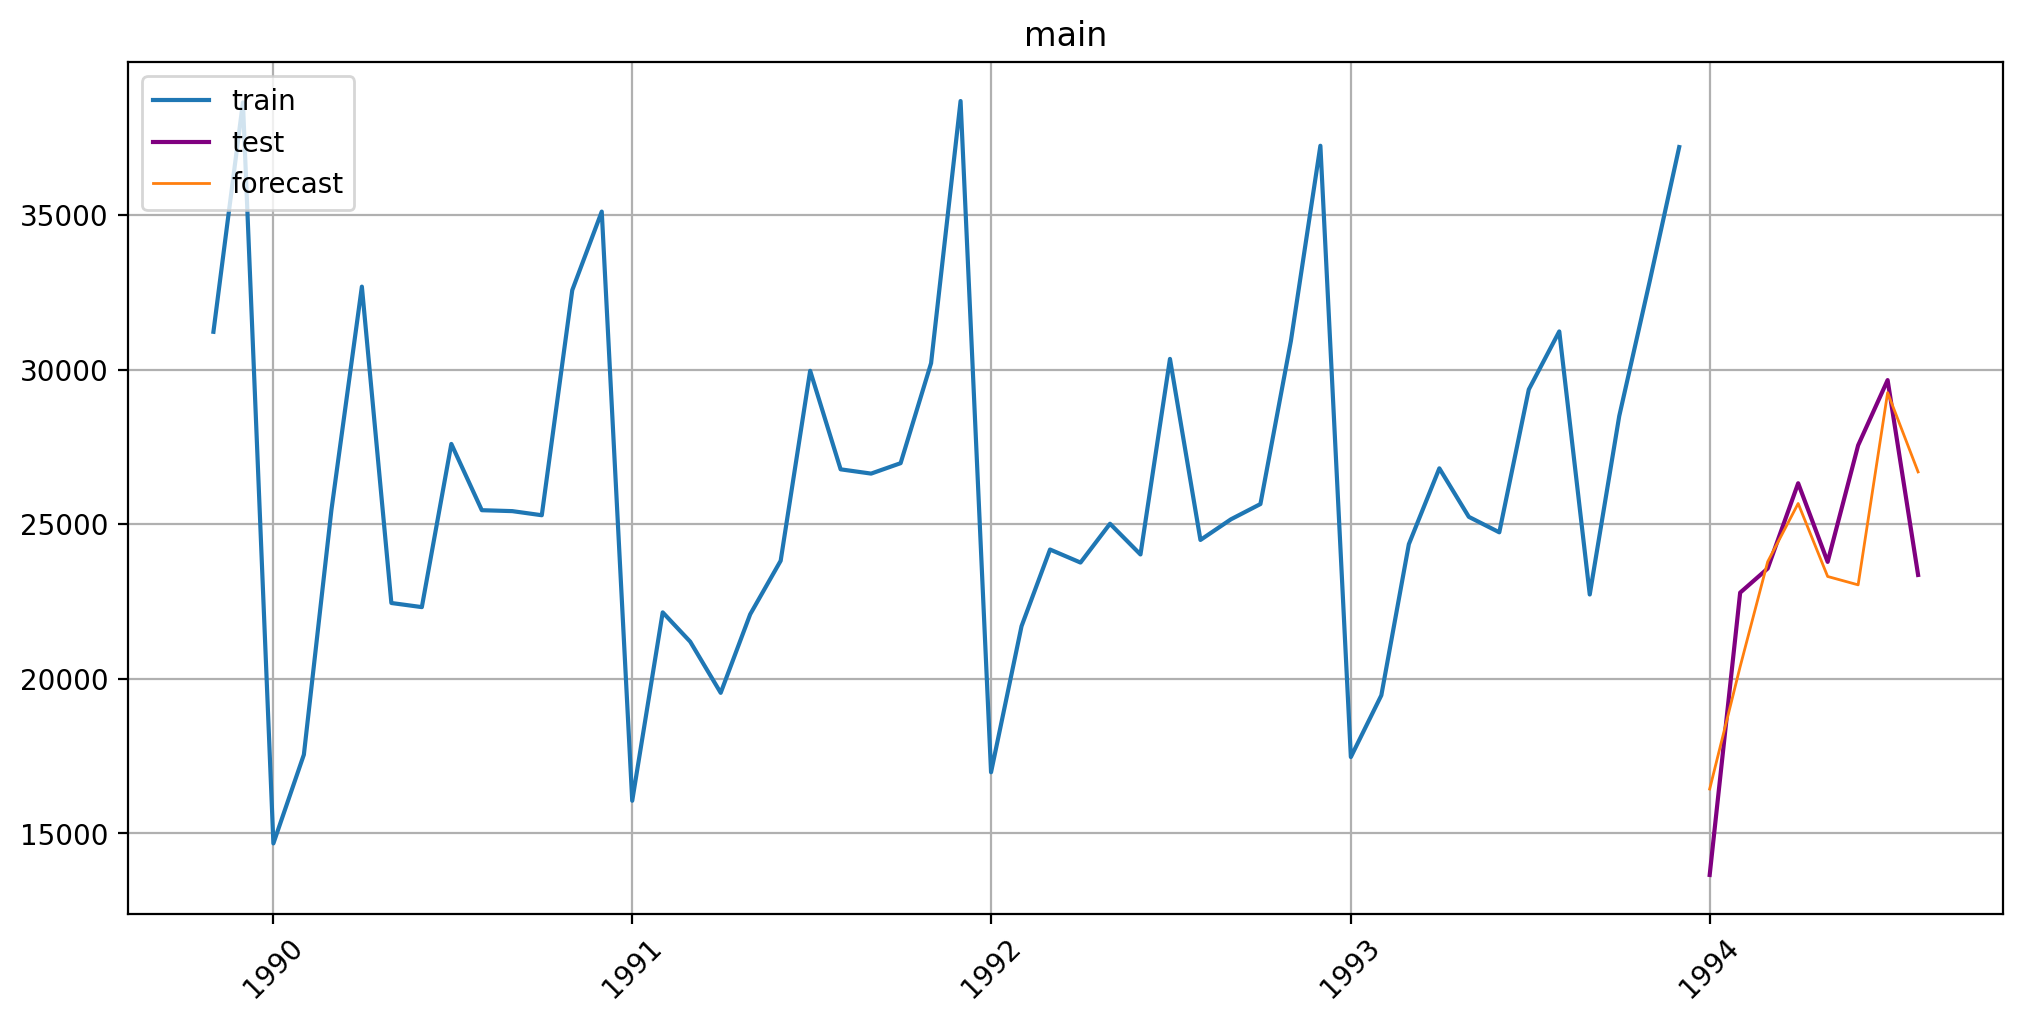

In [14]:
plot_forecast(forecast_ts, test_ts, train_ts, n_train_samples=50)

          Модель SARIMAX

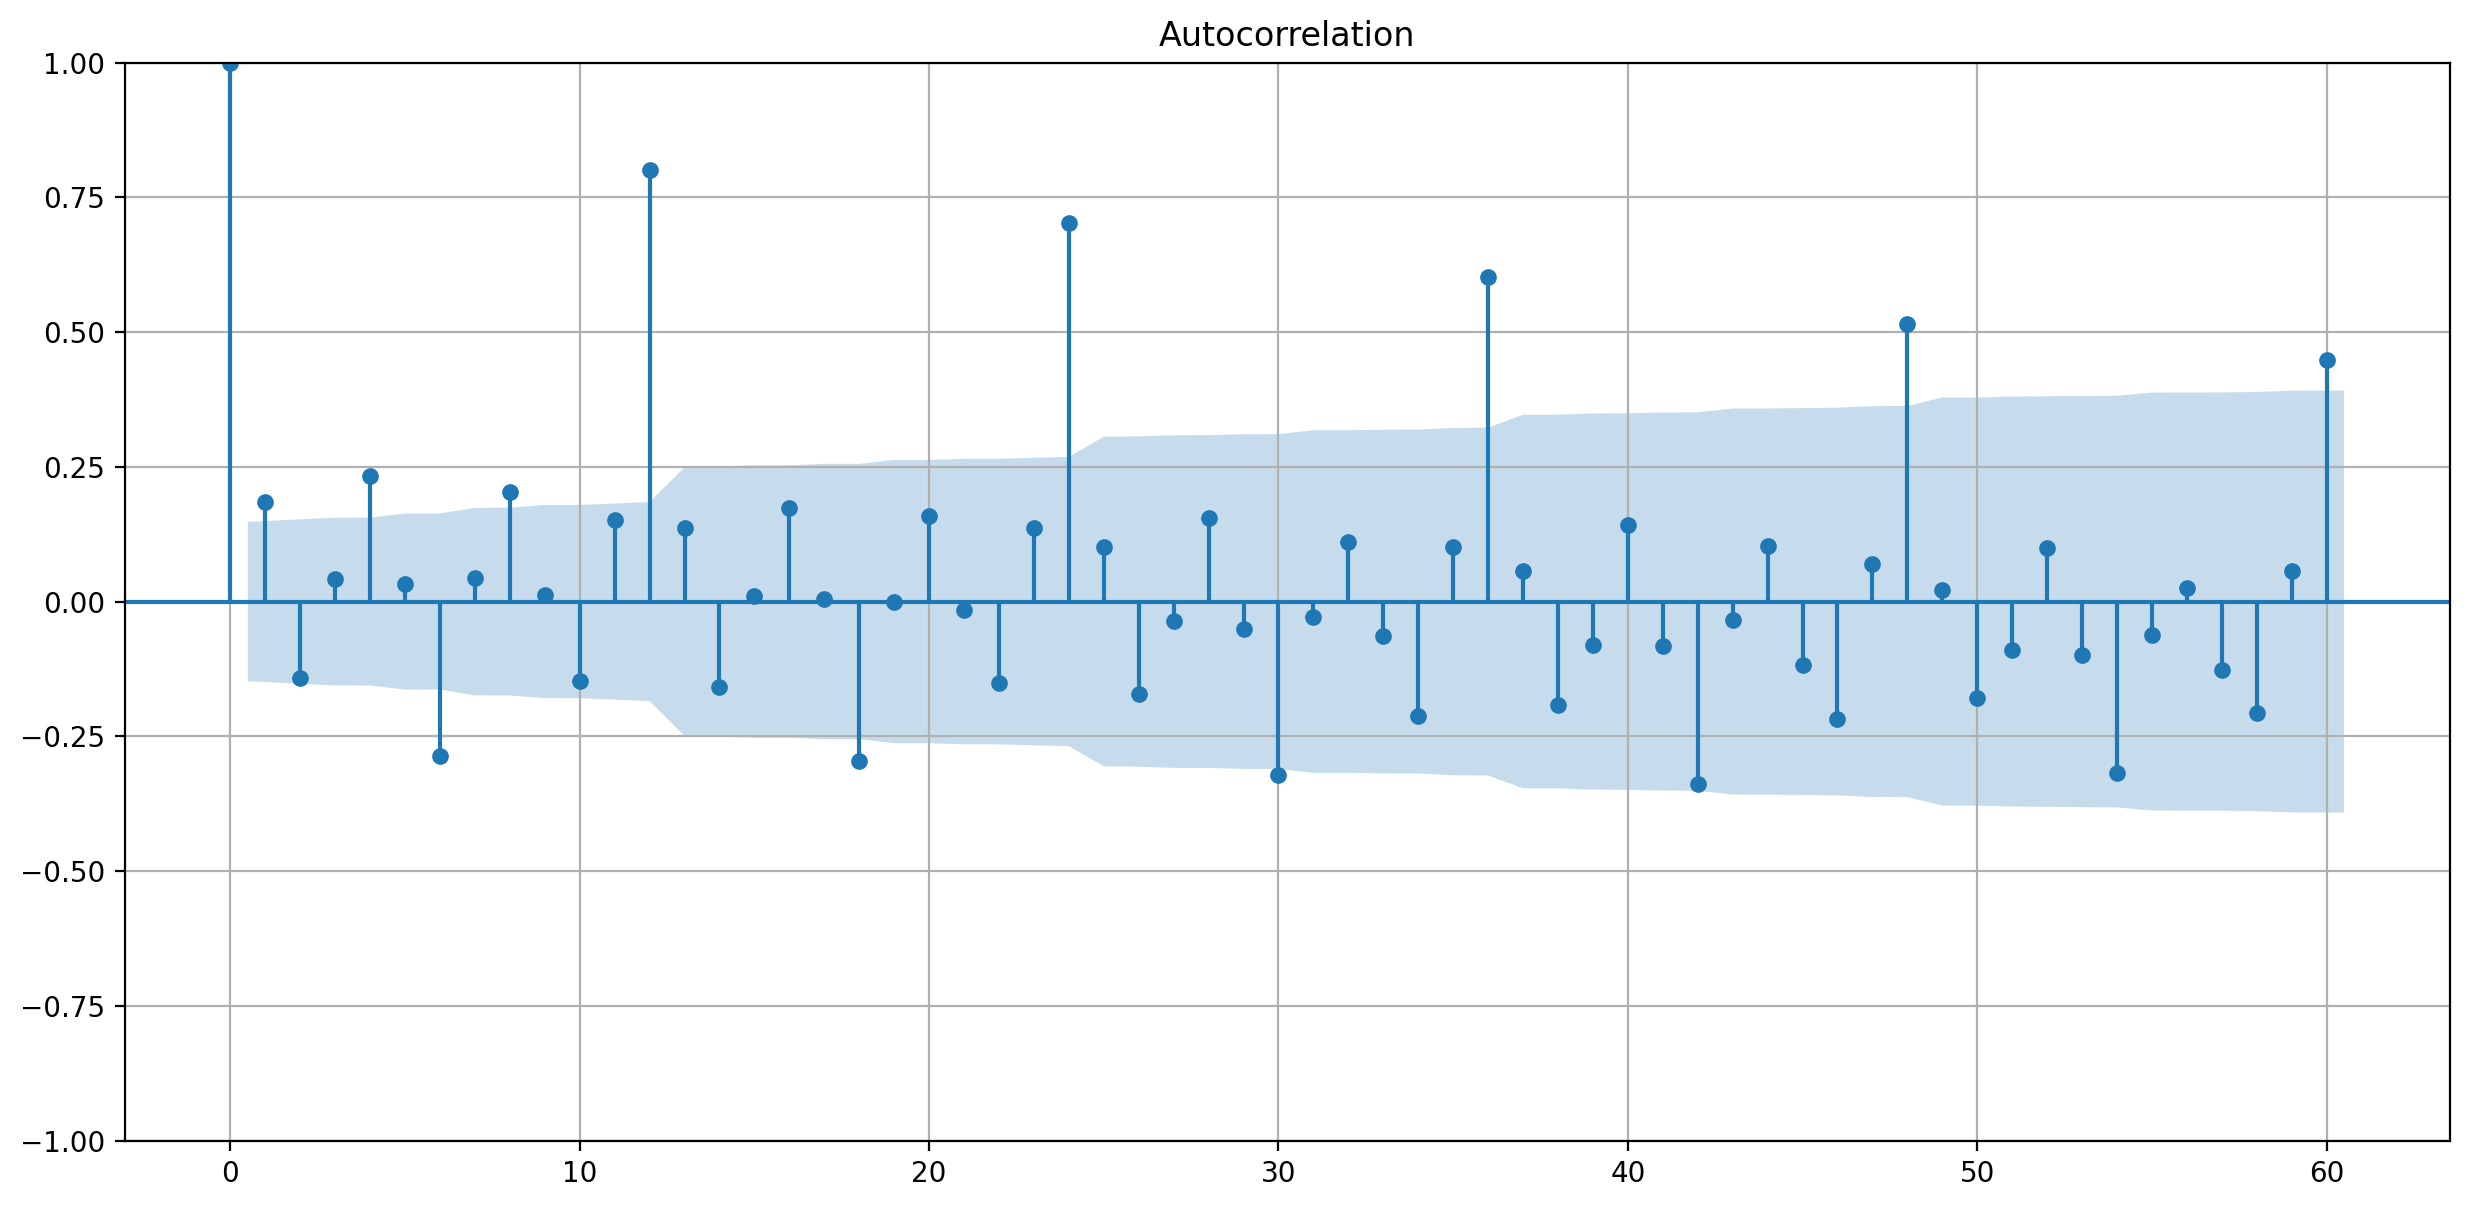

In [11]:
# автокорреляционная функция ее можно было сделать в начале тестов
#видна годовая сезонность

import matplotlib.pyplot as plt

_ = plot_acf(original_df.target, lags=60)
plt.grid()

In [29]:
from etna.models import SARIMAXModel

model = SARIMAXModel(order=(1, 1, 1), 
                            # MA(1), AR(1), d=1
                     seasonal_order=(1, 1, 0, 12))  
                                    # MA(0), AR(1), d=1, s = 12,
                  


model.fit(train_ts)

SARIMAXModel(order = (1, 1, 1), seasonal_order = (1, 1, 0, 12), trend = None, measurement_error = False, time_varying_regression = False, mle_regression = True, simple_differencing = False, enforce_stationarity = True, enforce_invertibility = True, hamilton_representation = False, concentrate_scale = False, trend_offset = 1, use_exact_diffuse = False, missing = 'none', validate_specification = True, fit_params = {}, )

In [17]:
future_ts = train_ts.make_future(HORIZON)
# ХАК: временно добавляем np.NaN обратно
if not hasattr(np, 'NaN'):
    np.NaN = np.nan

# Теперь ваш код должен работать
try:
    # Ваш код с моделью
    forecast_ts = model.forecast(future_ts)
except AttributeError as e:
    if "np.NaN" in str(e):
        print("Ошибка с np.NaN, применяем исправление...")
        # Альтернативный способ: патчим проблемный модуль
        import statsmodels
        if hasattr(statsmodels, 'NaN'):
            statsmodels.NaN = np.nan
    raise
forecast_ts

segment,main
feature,target
timestamp,
1994-01-01,17817.239461
1994-02-01,21239.541916
1994-03-01,24641.425168
1994-04-01,26170.784129
1994-05-01,24934.235121
1994-06-01,24651.882268
1994-07-01,30435.473055
1994-08-01,28559.516926


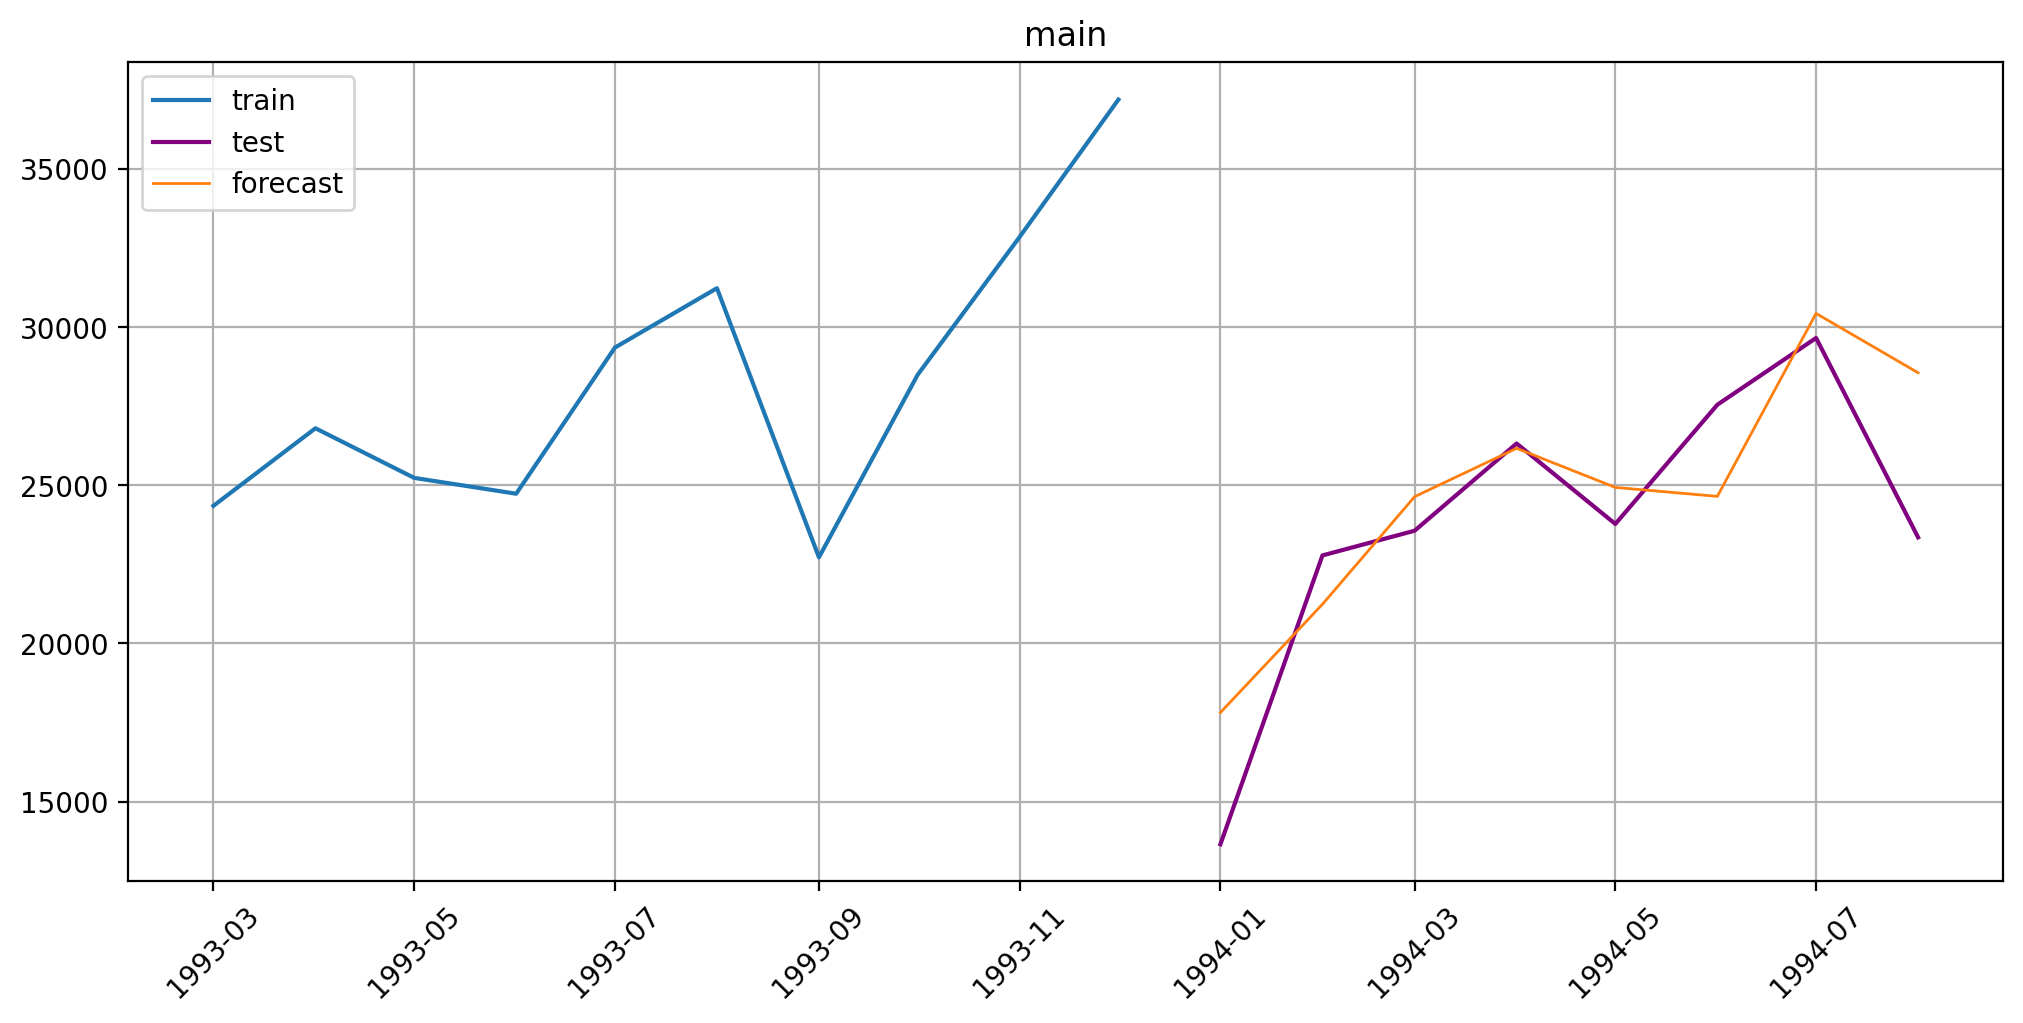

In [49]:
smape(y_true=test_ts, y_pred=forecast_ts)

plot_forecast(forecast_ts, test_ts, train_ts, n_train_samples=10)

!!!!!!!!!!!!!!!!!!Модель Хольта-Винтерса

In [16]:
model = HoltWintersModel(seasonal='additive',
                         trend='additive',
                         seasonal_periods=12, 
                         smoothing_level=0.05,
                         smoothing_trend=0.01,
                         smoothing_seasonal=0.35)

model.fit(train_ts)

future_ts = train_ts.make_future(future_steps=HORIZON,
                                 tail_steps=model.context_size)



In [14]:
# ХАК: временно добавляем np.NaN обратно
if not hasattr(np, 'NaN'):
    np.NaN = np.nan

# Теперь ваш код должен работать
try:
    # Ваш код с моделью
    forecast_ts = model.forecast(future_ts)
except AttributeError as e:
    if "np.NaN" in str(e):
        print("Ошибка с np.NaN, применяем исправление...")
        # Альтернативный способ: патчим проблемный модуль
        import statsmodels
        if hasattr(statsmodels, 'NaN'):
            statsmodels.NaN = np.nan
    raise

In [18]:
smape(y_true=test_ts, y_pred=forecast_ts)

{'main': np.float64(9.625493112201134)}

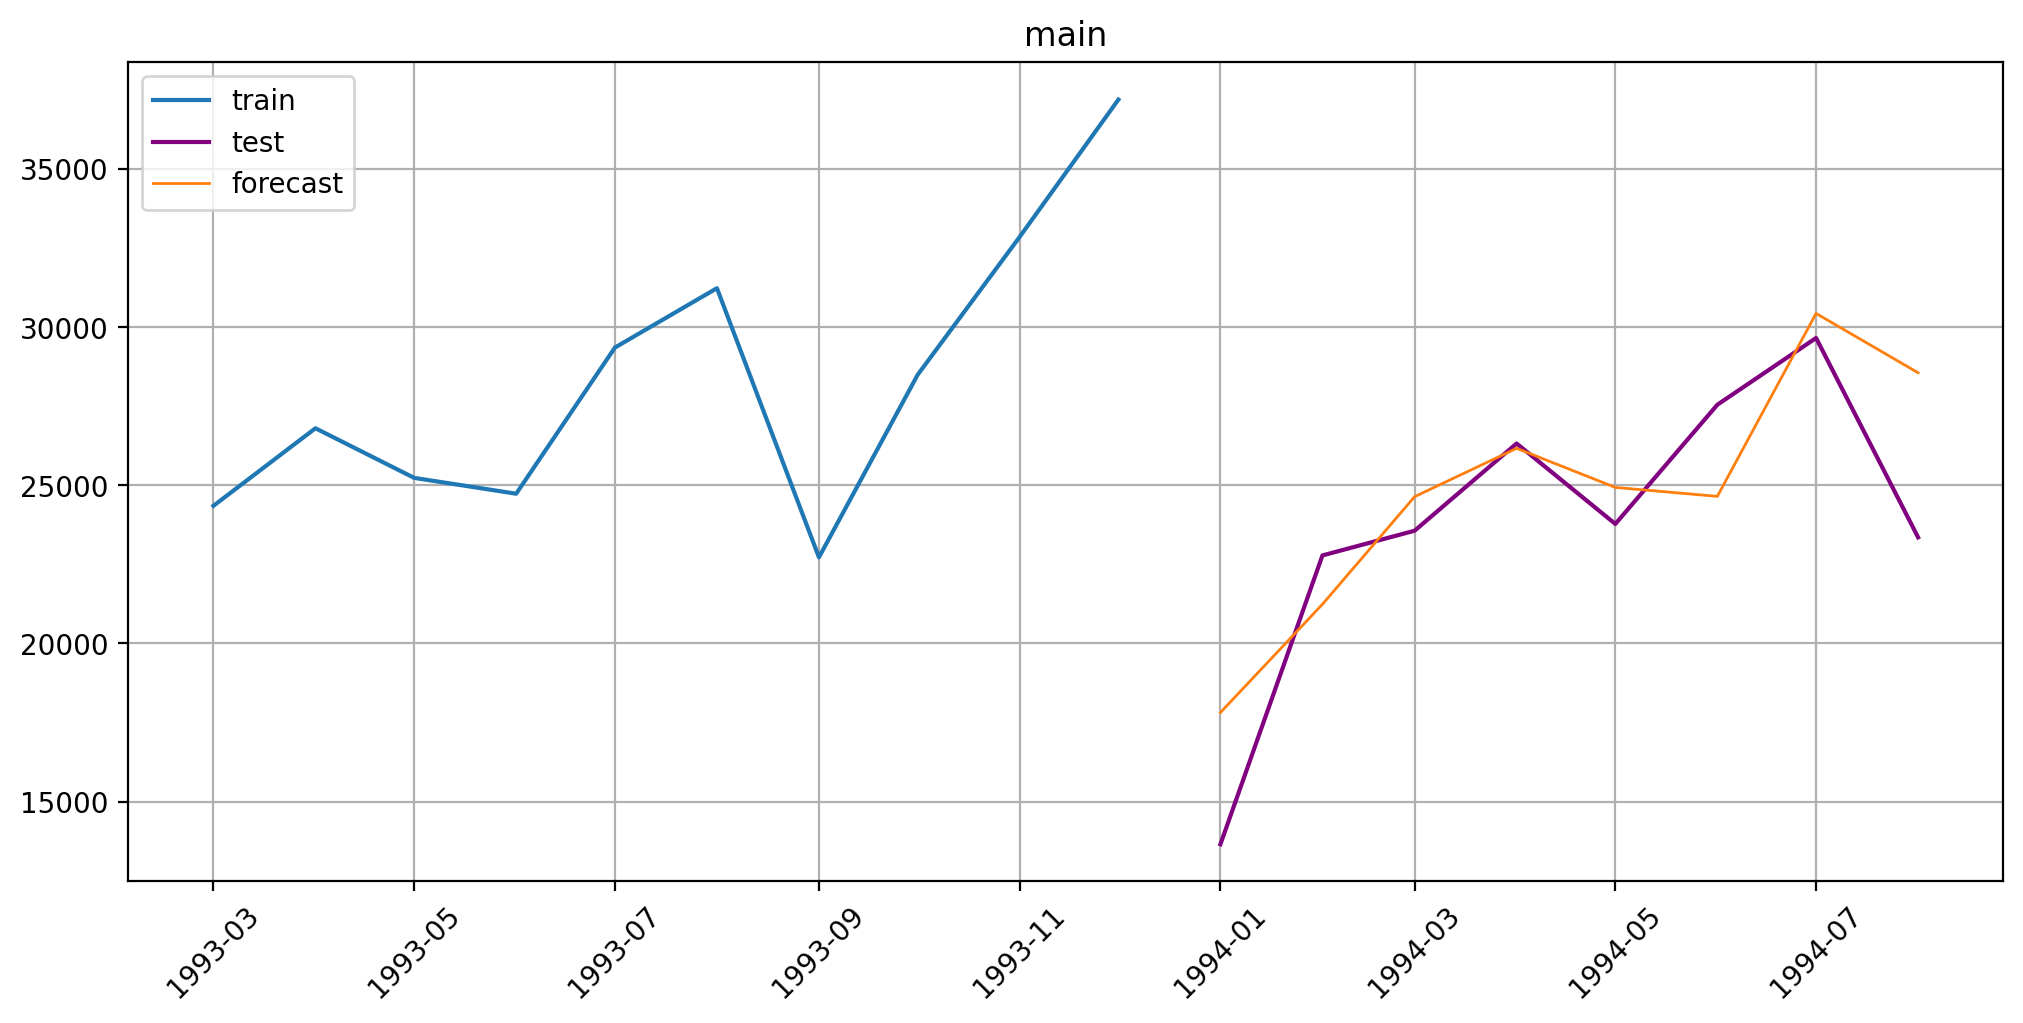

In [53]:
plot_forecast(forecast_ts, test_ts, train_ts, n_train_samples=10)

!!!!!!!!!!!!!Модель Prophet

In [168]:
# ХАК: временно добавляем np.NaN обратно
if not hasattr(np, 'NaN'):
    np.NaN = np.nan

# Теперь ваш код должен работать
try:
    # Ваш код с моделью
    forecast_ts = model.forecast(future_ts)
except AttributeError as e:
    if "np.NaN" in str(e):
        print("Ошибка с np.NaN, применяем исправление...")
        # Альтернативный способ: патчим проблемный модуль
        import statsmodels
        if hasattr(statsmodels, 'NaN'):
            statsmodels.NaN = np.nan
    raise

In [19]:
model = ProphetModel()
model.fit(train_ts)
future_ts = train_ts.make_future(HORIZON)
forecast_ts = model.forecast(future_ts)


16:43:09 - cmdstanpy - INFO - Chain [1] start processing


16:43:09 - cmdstanpy - INFO - Chain [1] done processing


In [20]:
smape(y_true=test_ts, y_pred=forecast_ts)

{'main': np.float64(10.629157584538678)}

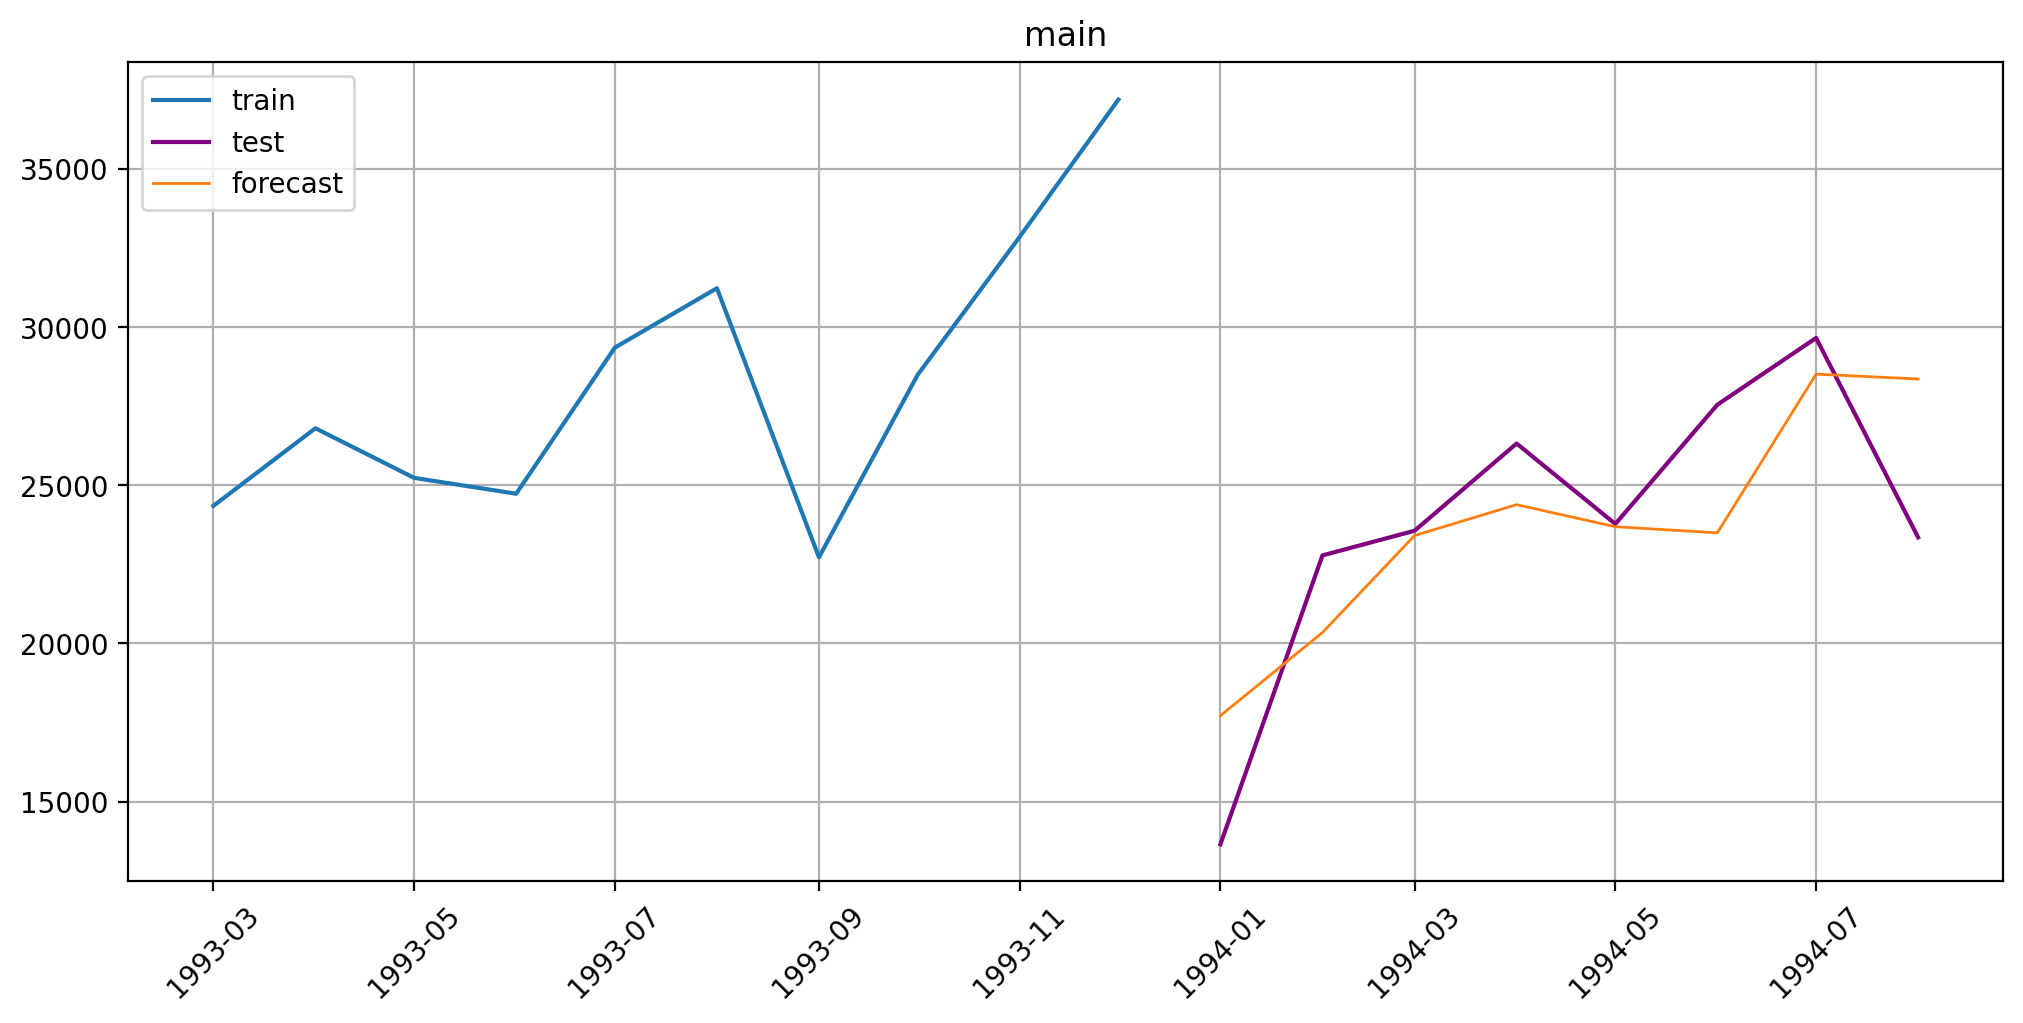

In [21]:
plot_forecast(forecast_ts, test_ts, 
              train_ts, n_train_samples=10)

!!!!!!!!Pipelinining

In [22]:
pipeline = Pipeline(model=model, transforms=[], horizon=HORIZON)

In [86]:
ts

segment,main
feature,target
timestamp,
1980-01-01,15136.0
1980-02-01,16733.0
1980-03-01,20016.0
1980-04-01,17708.0
1980-05-01,18019.0
...,...
1994-04-01,26323.0
1994-05-01,23779.0


In [ ]:
# ✅ Правильное создание метрик и backtest
metrics_list = [MAE(), MSE(), SMAPE()]

result = pipeline.backtest(
    ts=ts,
    metrics=metrics_list,  # Должен быть список объектов метрик ETNA
    n_folds=3
)

16:43:38 - cmdstanpy - INFO - Chain [1] start processing
16:43:38 - cmdstanpy - INFO - Chain [1] done processing
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.1s
16:43:38 - cmdstanpy - INFO - Chain [1] start processing
16:43:38 - cmdstanpy - INFO - Chain [1] done processing
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    0.1s
16:43:38 - cmdstanpy - INFO - Chain [1] start processing
16:43:38 - cmdstanpy - INFO - Chain [1] done processing
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.2s finished


[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished


In [152]:
print(f"Тип результата: {type(result)}")

Тип результата: <class 'dict'>


In [153]:
# 4. Форматированный вывод
for k, v in result.items():
    print(f"{k:15}: {type(v).__name__:10} | {'длина ' + str(len(v)) if hasattr(v, '__len__') else ''}")

metrics        : DataFrame  | длина 3
forecasts      : list       | длина 3
fold_info      : DataFrame  | длина 3
pipelines      : list       | длина 3


In [31]:
# Извлекаем метрики из словаря
if 'metrics' in result:
    metrics_df = result['metrics']
    print(f"✅ Метрики получены, тип: {type(metrics_df)}")
    
    # Если это уже DataFrame, отлично
    if isinstance(metrics_df, pd.DataFrame):
        print(metrics_df)
    else:
        # Если нет, преобразуем
        metrics_df = pd.DataFrame(metrics_df)
        print(metrics_df)

✅ Метрики получены, тип: <class 'pandas.core.frame.DataFrame'>
  segment          MAE           MSE      SMAPE  fold_number
0    main  1312.354030  3.272119e+06   4.923615            0
0    main  2028.840099  4.575822e+06   7.224212            1
0    main  2359.773986  8.627703e+06  10.629158            2


In [158]:
def get_all_forecasts_as_ts(backtest_result):
    """
    Извлекает все прогнозы как список TSDataset
    
    Returns:
    --------
    list : список TSDataset объектов для каждого фолда
    """
    forecast_ts_list = []
    
    # Случай 1: словарь (ETNA 3.x)
    if isinstance(backtest_result, dict):
        for key in ['forecasts', 'forecast']:
            if key in backtest_result:
                forecasts = backtest_result[key]
                if isinstance(forecasts, list):
                    for i, f in enumerate(forecasts):
                        if isinstance(f, TSDataset):
                            forecast_ts_list.append(f)
                            print(f"✅ Фолд {i+1}: TSDataset")
                        elif hasattr(f, 'to_pandas'):
                            # Пробуем преобразовать
                            try:
                                df = f.to_pandas()
                                freq = pd.infer_freq(df.index) if hasattr(df, 'index') else 'D'
                                forecast_ts = TSDataset(df, freq=freq)
                                forecast_ts_list.append(forecast_ts)
                                print(f"✅ Фолд {i+1}: преобразован в TSDataset")
                            except:
                                print(f"❌ Фолд {i+1}: не удалось преобразовать")
    
    # Случай 2: кортеж (ETNA 2.x)
    elif isinstance(backtest_result, tuple) and len(backtest_result) >= 2:
        forecasts = backtest_result[1]
        if isinstance(forecasts, list):
            for i, f in enumerate(forecasts):
                if isinstance(f, TSDataset):
                    forecast_ts_list.append(f)
                elif hasattr(f, 'to_pandas'):
                    try:
                        df = f.to_pandas()
                        freq = pd.infer_freq(df.index) if hasattr(df, 'index') else 'D'
                        forecast_ts = TSDataset(df, freq=freq)
                        forecast_ts_list.append(forecast_ts)
                    except:
                        pass
    
    print(f"\n📊 Всего получено {len(forecast_ts_list)} TSDataset прогнозов")
    return forecast_ts_list



In [161]:
# Использование
all_forecasts = get_all_forecasts_as_ts(result)

✅ Фолд 1: TSDataset
✅ Фолд 2: TSDataset
✅ Фолд 3: TSDataset

📊 Всего получено 3 TSDataset прогнозов


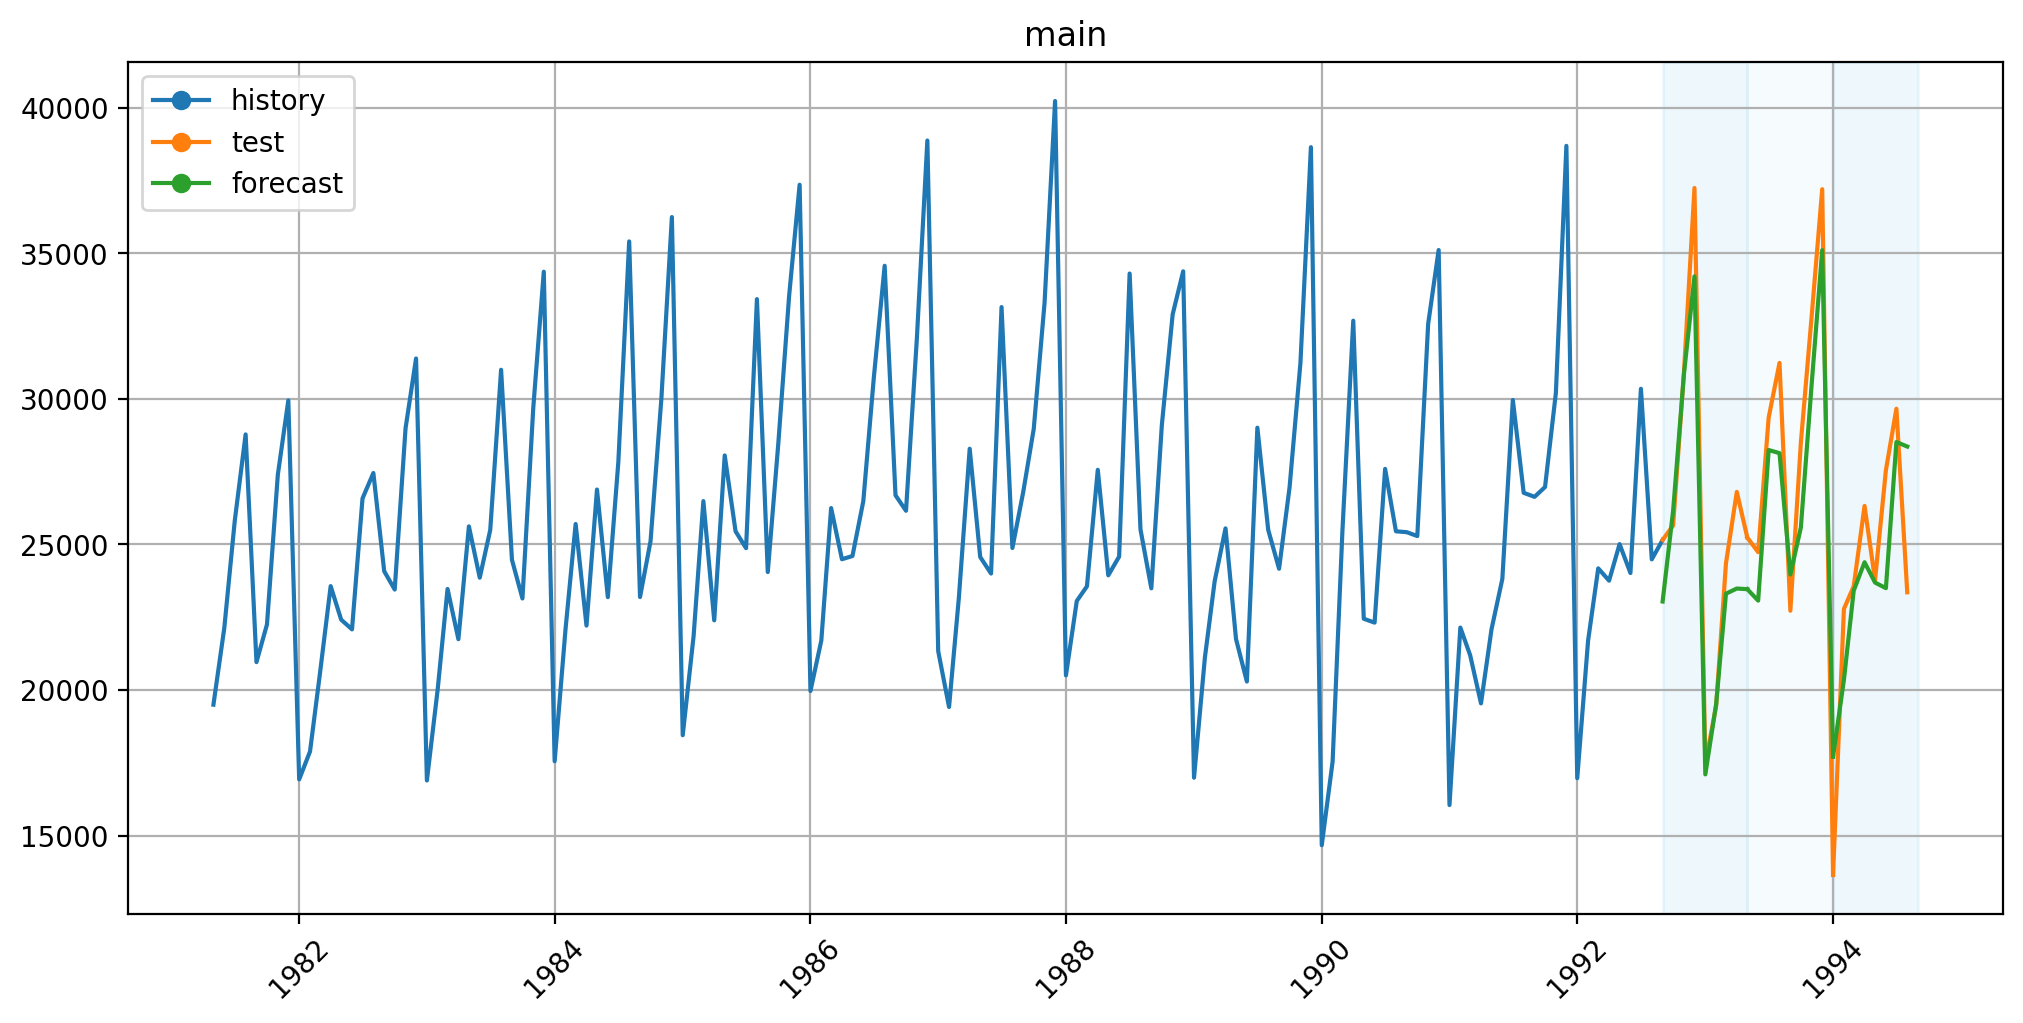

In [165]:
plot_backtest(all_forecasts, ts, history_len=137)

!!!!!!! Модель CatBoost градиентный бустинг

In [18]:
#Создание и оценка важности признаков:

mean7 = MeanTransform(in_column='target', 
                      window=7, 
                      out_column='mean_07')

mean8 = MeanTransform(in_column='target', 
                      window=8, 
                      out_column='mean_08')
mean9 = MeanTransform(in_column='target', 
                      window=9, 
                      out_column='mean_09')
mean10 = MeanTransform(in_column='target', 
                      window=10, 
                      out_column='mean_10')
mean11 = MeanTransform(in_column='target', 
                      window=11, 
                      out_column='mean_11')

lags = LagTransform(in_column='target', 
                    lags=list(range(6, 10, 1)), 
                    out_column='lag')

train_ts.fit_transform([mean7, mean8, mean9, mean10, mean11, lags])
train_ts.tail()

segment        main                                                      \
feature       lag_6    lag_7    lag_8    lag_9       mean_07    mean_08   
timestamp                                                                 
1993-08-01  19463.0  17466.0  37240.0  30923.0  25883.000000  24830.875   
1993-09-01  24352.0  19463.0  17466.0  37240.0  26348.857143  25488.125   
1993-10-01  26805.0  24352.0  19463.0  17466.0  26940.857143  26617.250   
1993-11-01  25236.0  26805.0  24352.0  19463.0  27805.428571  27680.375   
1993-12-01  24735.0  25236.0  26805.0  24352.0  29514.285714  28979.500   

segment                                                   
feature          mean_09  mean_10       mean_11   target  
timestamp                                                 
1993-08-01  26209.666667  26681.0  26587.272727  31234.0  
1993-09-01  24596.777778  25861.1  26321.272727  22724.0  
1993-10-01  25822.333333  24986.7  26100.636364  28496.0  
1993-11-01  27310.555556  26525.8  25702.181818  32857.0  
1993-12-01  28737.888889  28299.3  27496.000000  37198.0

In [167]:
train_ts.head(10)

segment        main                                                         \
feature       lag_6    lag_7    lag_8    lag_9       mean_07       mean_08   
timestamp                                                                    
1980-01-01      NaN      NaN      NaN      NaN  15136.000000  15136.000000   
1980-02-01      NaN      NaN      NaN      NaN  15934.500000  15934.500000   
1980-03-01      NaN      NaN      NaN      NaN  17295.000000  17295.000000   
1980-04-01      NaN      NaN      NaN      NaN  17398.250000  17398.250000   
1980-05-01      NaN      NaN      NaN      NaN  17522.400000  17522.400000   
1980-06-01      NaN      NaN      NaN      NaN  17806.500000  17806.500000   
1980-07-01  15136.0      NaN      NaN      NaN  18533.142857  18533.142857   
1980-08-01  16733.0  15136.0      NaN      NaN  19762.142857  19183.875000   
1980-09-01  20016.0  16733.0  15136.0      NaN  20390.714286  19933.500000   
1980-10-01  17708.0  20016.0  16733.0  15136.0  20758.571429  20665.750000   

segment                                                        
feature          mean_09       mean_10       mean_11   target  
timestamp                                                      
1980-01-01  15136.000000  15136.000000  15136.000000  15136.0  
1980-02-01  15934.500000  15934.500000  15934.500000  16733.0  
1980-03-01  17295.000000  17295.000000  17295.000000  20016.0  
1980-04-01  17398.250000  17398.250000  17398.250000  17708.0  
1980-05-01  17522.400000  17522.400000  17522.400000  18019.0  
1980-06-01  17806.500000  17806.500000  17806.500000  19227.0  
1980-07-01  18533.142857  18533.142857  18533.142857  22893.0  
1980-08-01  19183.875000  19183.875000  19183.875000  23739.0  
1980-09-01  19400.444444  19400.444444  19400.444444  21133.0  
1980-10-01  20228.777778  19719.500000  19719.500000  22591.0

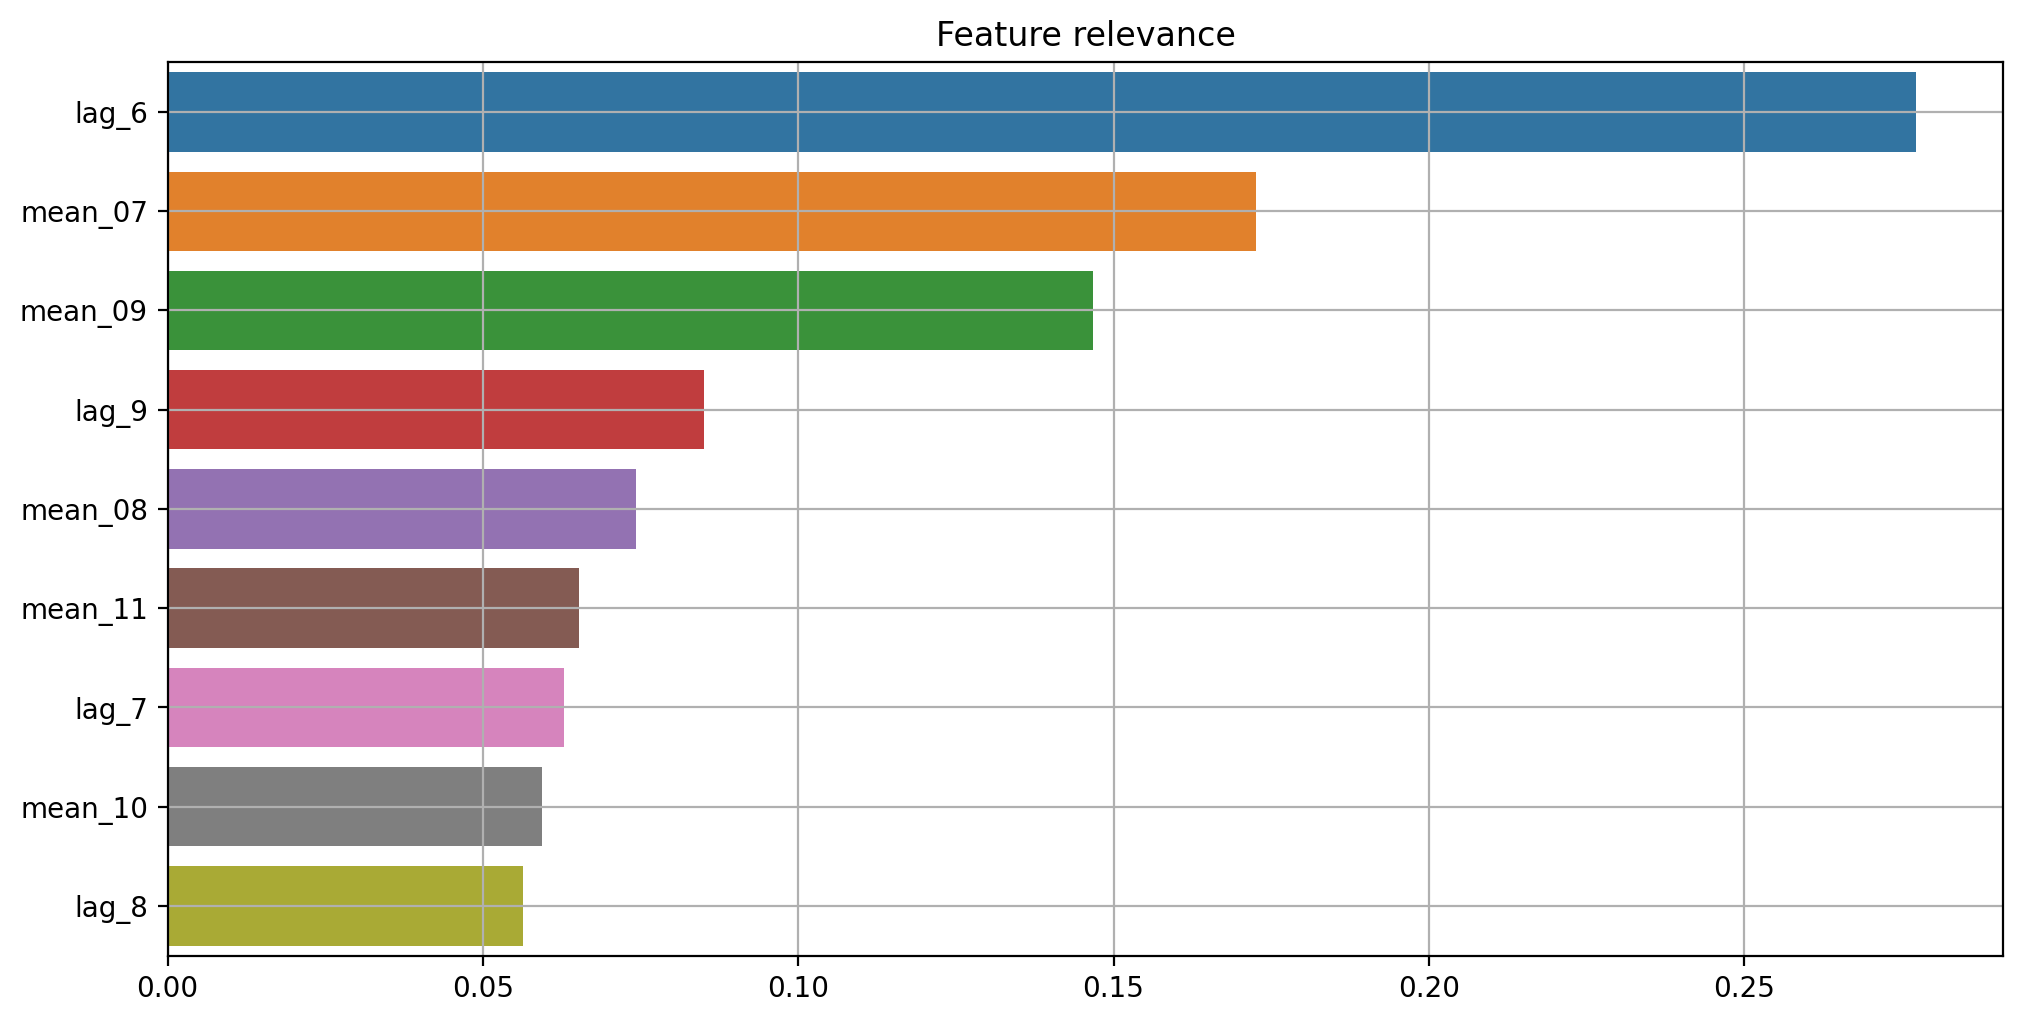

In [170]:
# выведем график топ-20 важных признаков
plot_feature_relevance(
    ts=train_ts,
    relevance_table=ModelRelevanceTable(),
    normalized=True,
    top_k=20,
    relevance_params=dict(
        model=RandomForestRegressor(n_estimators=100))
)

In [ ]:
#Catboost model (модель градиентного бустинга):

model = CatBoostMultiSegmentModel(loss_function='MAE',
                                  n_estimators=600,
                                  learning_rate=0.05,
                                  depth=9, 
                                  random_seed=42)
model.fit(train_ts)

future_ts = train_ts.make_future(
    HORIZON, 
    [mean7, mean8, mean9, 
     mean10, mean11, lags])

In [ ]:
forecast_ts = model.forecast(future_ts)

In [172]:
smape(y_true=test_ts, y_pred=forecast_ts)

{'main': np.float64(13.592002795451918)}

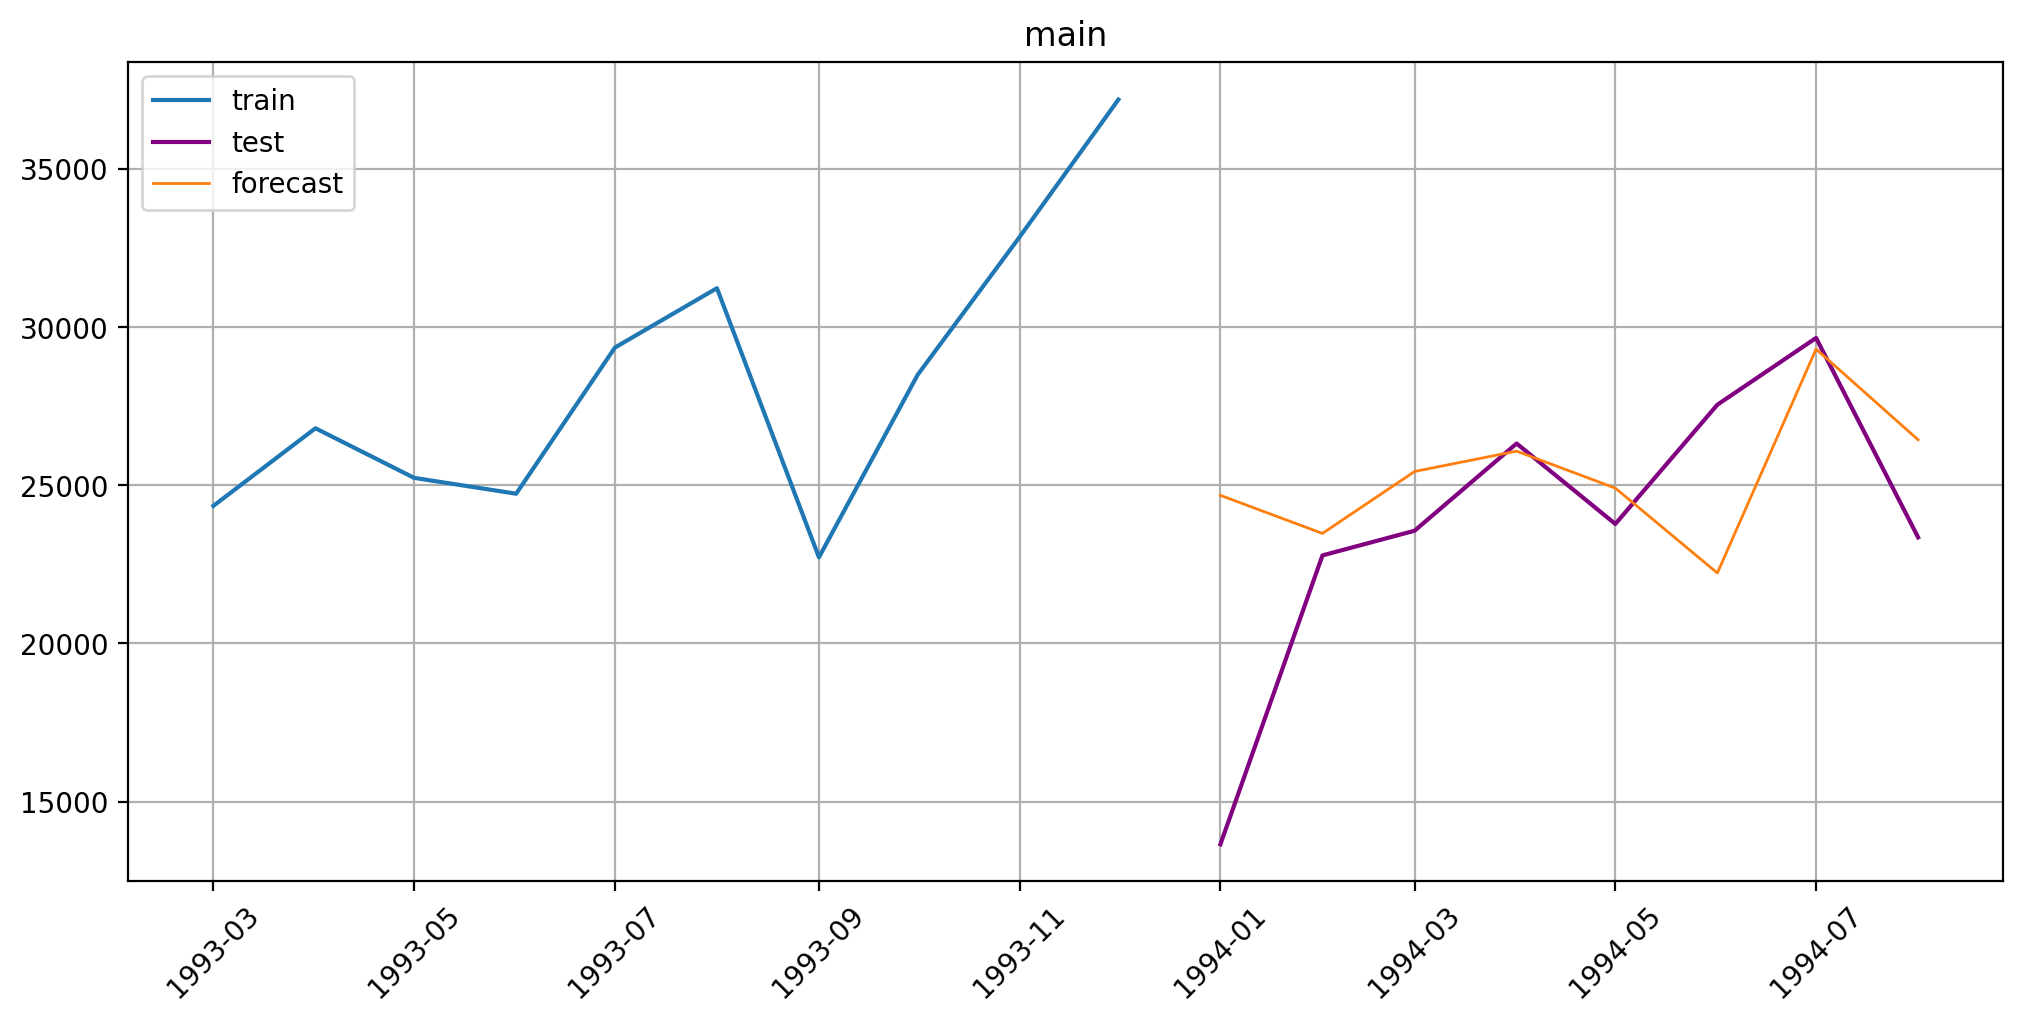

In [173]:
plot_forecast(forecast_ts, test_ts, train_ts, n_train_samples=10)

Подбор гиперпараметров:

In [16]:
def etna_validation_optimize(ts,
                             train_start,
                             train_end,
                             valid_start,
                             valid_end,
                             model, 
                             horizon, 
                             transfrms,
                             metrics):
    """
    Выполняет подбор гиперпараметра - набора преобразований/
    признаков с помощью валидационной выборки.  
    """
    
    best_score = np.inf
    
    for trans in transfrms:
        train_ts, valid_ts = ts.train_test_split(train_start=train_start,
                                                 train_end=train_end,
                                                 test_start=valid_start,
                                                 test_end=valid_end)
        pipe = Pipeline(
            model=model,
            transforms=trans,
            horizon=horizon)
    
        pipe.fit(train_ts)
        forecast_ts = pipe.forecast()     
        metrics_score = metrics(y_true=valid_ts, 
                                y_pred=forecast_ts).get('main')
        
        print(f"trans:\n{trans}")
        print(f"{metrics.__class__.__name__}: {metrics_score}\n")

        if metrics_score < best_score:
            best_score = metrics_score
            best_parameters = {'trans': trans}
    
    print(f"Наилучший набор преобразований/признаков:\n{best_parameters}\n")
    print(f"Лучшее значение {metrics.__class__.__name__}: {best_score:.4f}\n")


In [19]:
lags = LagTransform(in_column='target', 
                    lags=list(range(6, 10, 1)), 
                    out_column='lag')

lags2 = LagTransform(in_column='target', 
                     lags=list(range(8, 13, 1)), 
                     out_column='lag')


etna_validation_optimize(ts,
                         train_start='1980-01-01',
                         train_end='1993-04-01',
                         valid_start='1993-05-01',
                         valid_end='1993-12-01',
                         model=model, 
                         horizon=HORIZON, 
                         transfrms=[[lags, mean8], [lags2, mean8]],
                         metrics=SMAPE())

trans:
[LagTransform(in_column = 'target', lags = [6, 7, 8, 9], out_column = 'lag', ), MeanTransform(in_column = 'target', window = 8, seasonality = 1, alpha = 1, min_periods = 1, fillna = 0, out_column = 'mean_08', )]
SMAPE: 6.734044939393648

trans:
[LagTransform(in_column = 'target', lags = [8, 9, 10, 11, 12], out_column = 'lag', ), MeanTransform(in_column = 'target', window = 8, seasonality = 1, alpha = 1, min_periods = 1, fillna = 0, out_column = 'mean_08', )]
SMAPE: 6.748423083733391

Наилучший набор преобразований/признаков:
{'trans': [LagTransform(in_column = 'target', lags = [6, 7, 8, 9], out_column = 'lag', ), MeanTransform(in_column = 'target', window = 8, seasonality = 1, alpha = 1, min_periods = 1, fillna = 0, out_column = 'mean_08', )]}

Лучшее значение SMAPE: 6.7340



Подбор гиперпараметров с помощью перекрестной проверки

In [20]:
transforms = [lags, mean8]

pipeline = Pipeline(model=model, 
                    transforms=transforms, 
                    horizon=HORIZON)

In [22]:
metrics_list = [MAE(), MSE(), SMAPE()]

result = pipeline.backtest(
    ts=train_ts,
    metrics=metrics_list,  # Должен быть список объектов метрик ETNA
    n_folds=3
)

[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.2s finished


[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:    0.4s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.4s finished
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished


In [23]:
# 4. Форматированный вывод
for k, v in result.items():
    print(f"{k:15}: {type(v).__name__:10} | {'длина ' + str(len(v)) if hasattr(v, '__len__') else ''}")

metrics        : DataFrame  | длина 3
forecasts      : list       | длина 3
fold_info      : DataFrame  | длина 3
pipelines      : list       | длина 3


In [24]:
# Извлекаем метрики из словаря
if 'metrics' in result:
    metrics_df = result['metrics']
    print(f"✅ Метрики получены, тип: {type(metrics_df)}")
    
    # Если это уже DataFrame, отлично
    if isinstance(metrics_df, pd.DataFrame):
        print(metrics_df)
    else:
        # Если нет, преобразуем
        metrics_df = pd.DataFrame(metrics_df)
        print(metrics_df)

✅ Метрики получены, тип: <class 'pandas.core.frame.DataFrame'>
  segment          MAE           MSE     SMAPE  fold_number
0    main  1175.129083  1.883404e+06  4.868805            0
0    main   943.105455  1.276569e+06  3.869293            1
0    main  1834.481894  5.338815e+06  6.734045            2


In [25]:
transforms2 = [lags2, mean8]
pipeline2 = Pipeline(model=model, 
                     transforms=transforms2, 
                     horizon=HORIZON)
train_ts, test_ts = ts.train_test_split(train_start='1980-01-01',
                                        train_end='1993-12-01',
                                        test_start='1994-01-01',
                                        test_end='1994-08-01')

metrics_df2, forecast_df2, fold_info_df2 = pipeline2.backtest(
    mode='expand', ts=train_ts, metrics=[smape])

[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done   4 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done   5 tasks      | elapsed:    0.6s
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.6s finished
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done   4 tasks      | elapsed:    0.4s
[Parallel(n_jobs=1)]: Done   5 tasks      | elapsed:    0.5s
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.5s finished
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   4 tasks      | elapsed:    0.0s
[Paral

ValueError: too many values to unpack (expected 3)

Фукция обучения и оценки моделей

Объединение процедуры построения модели, оценки качества и визуализации прогнозов в одной функции

In [26]:
def train_and_evaluate_model(ts, 
                             model,
                             transforms,
                             horizon,
                             metrics,
                             print_metrics=False,
                             print_plots=False,
                             n_train_samples=None):
    """
    Обучает модель, вычисляет прогнозы для 
    тестовой выборки и строит график прогнозов.  
    """
    
    if not print_plots and n_train_samples is not None:
        raise ValueError(
            "Параметр n_train_samples задается при print_plots=True")
        
    train_ts, test_ts = ts.train_test_split(test_size=horizon)
    pipe = Pipeline(model=model,
                    transforms=transforms,
                    horizon=horizon)
    pipe.fit(train_ts)
    forecast_ts = pipe.forecast()
    
    segment_metrics = metrics(test_ts, forecast_ts)
    segment_metrics = pd.Series(segment_metrics)
    
    if print_metrics:
        print(segment_metrics.to_string())
        print("")
        print(f"Усредненная метрика:"
              f"{sum(segment_metrics) / len(segment_metrics)}")
    
    if print_plots:
        # визуализируем прогнозы, здесь n_train_samples
        # - n последних наблюдений в обучающей выборке
        plot_forecast(forecast_ts, test_ts, 
                      train_ts, n_train_samples=n_train_samples)


main    13.536414

Усредненная метрика:13.536413717462203


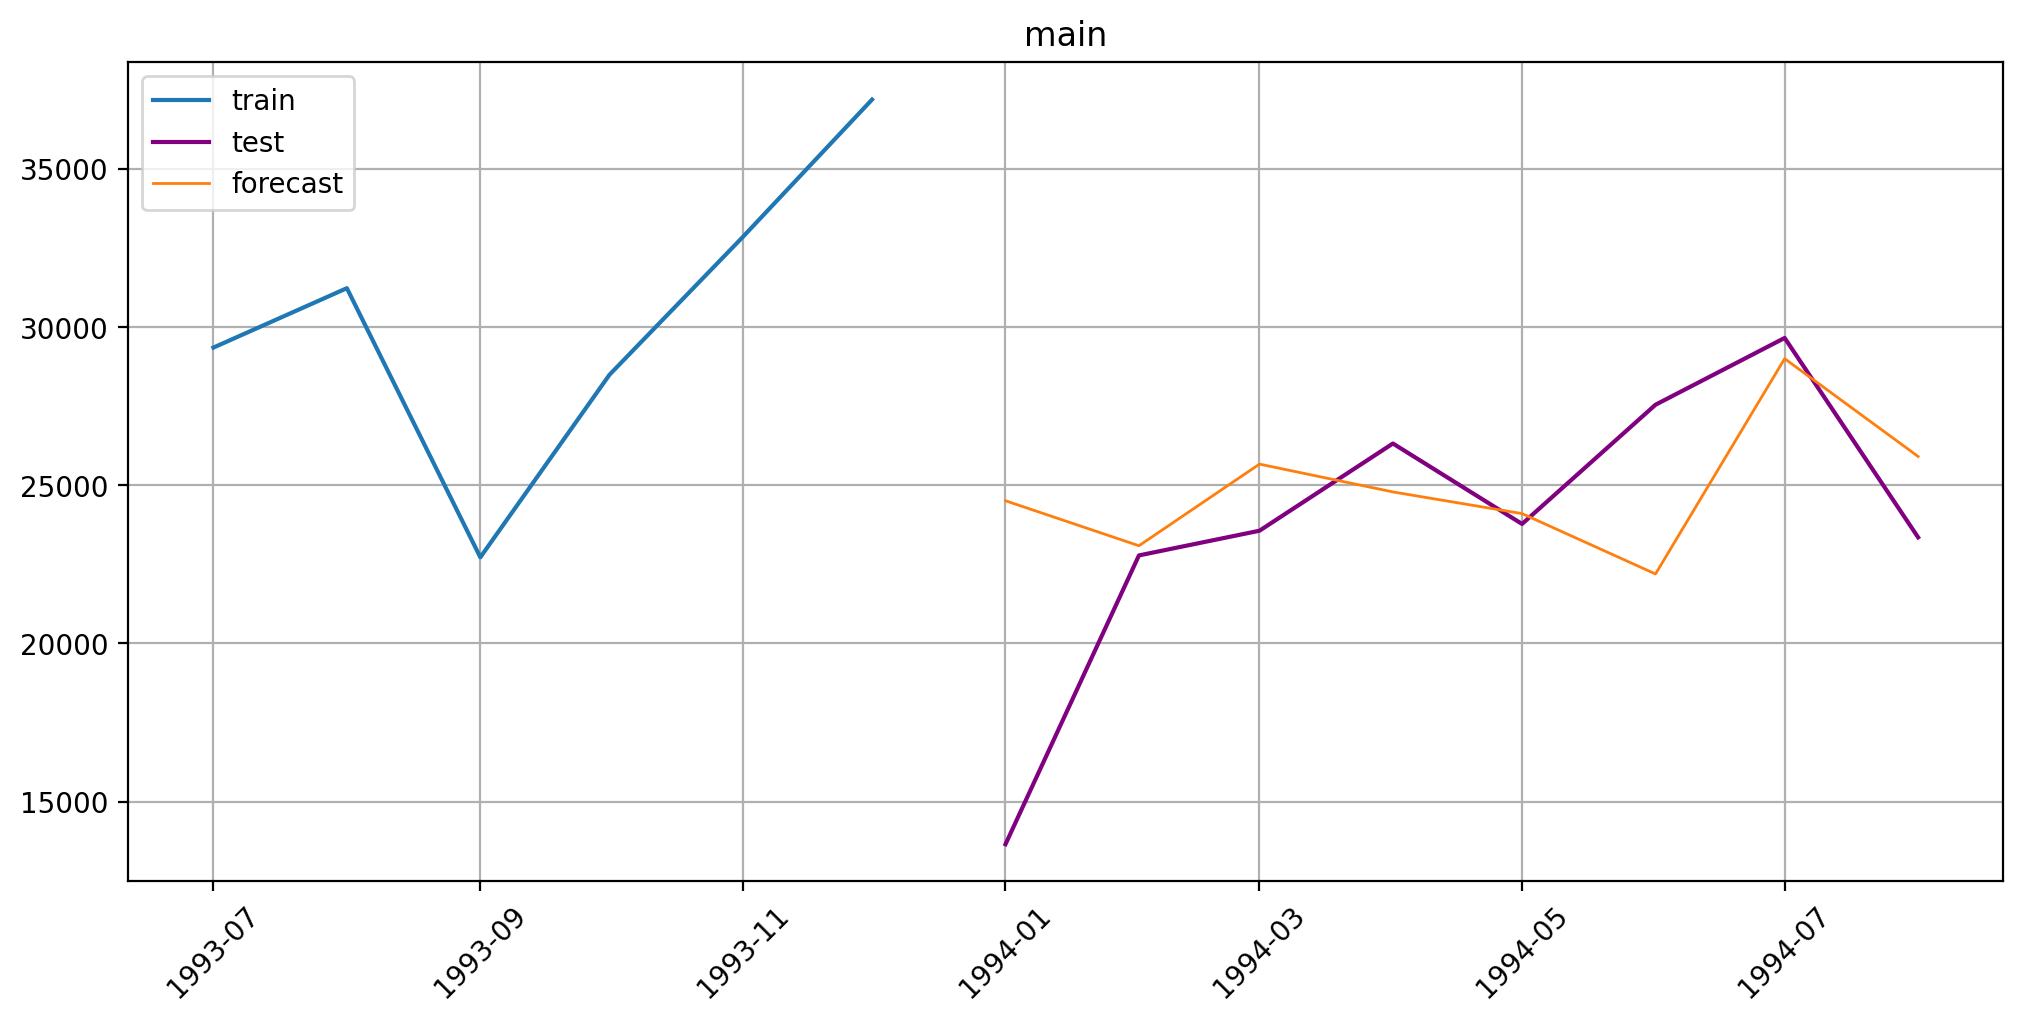

In [27]:
# создаем экземпляр класса CatBoostMultiSegmentModel
model = CatBoostMultiSegmentModel(loss_function='MAE',
                                  n_estimators=600,
                                  learning_rate=0.05,
                                  depth=9, 
                                  random_seed=42)

# задаем список преобразований
preprocess = [lags, mean8]

HORIZON = 8
smape = SMAPE()

# строим и оцениваем модель CatBoostMultiSegmentModel
train_and_evaluate_model(
    ts=ts, 
    model=model,
    transforms=preprocess,
    horizon=HORIZON,
    metrics=smape,
    print_metrics=True,
    print_plots=True,
    n_train_samples=6)

Итоговое сравнение моделей

In [30]:
naive_pipeline = Pipeline(
   model=NaiveModel(lag=12), transforms=[], horizon=HORIZON
)

prophet_pipeline = Pipeline(
    model=ProphetModel(), transforms=[], horizon=HORIZON
)

sma_seasonality_12_pipeline = Pipeline(
    model=SeasonalMovingAverageModel(window=5, seasonality=12), 
    transforms=[], horizon=HORIZON
)

sarimax_pipeline = Pipeline(
    model=SARIMAXModel(order=(0, 1, 1), 
                       seasonal_order=(0, 1, 1, 12)), 
    transforms=[], horizon=HORIZON
)

catboost_pipeline = Pipeline(
    model=CatBoostMultiSegmentModel(),
    transforms=[mean7, mean8, mean9, mean10, mean11, lags],
    horizon=HORIZON
)

In [31]:
pipeline_names = ['naive', 'prophet', 'sma_seasonality_12', 
                  'sarimax', 'catboost',]

pipelines = [naive_pipeline, prophet_pipeline,
             sma_seasonality_12_pipeline, 
             sarimax_pipeline, catboost_pipeline]

metrics = []

for pipeline in pipelines:
    metrics.append(
        pipeline.backtest(
            ts=ts, metrics=[MAE(), MSE(), SMAPE(), MAPE()], 
            n_folds=3, aggregate_metrics=True)
            [0].iloc[:, 1:])
    
metrics = pd.concat(metrics)
metrics.index = pipeline_names

[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished


KeyError: 0

Ансамбли

In [32]:
from etna.ensembles import VotingEnsemble
from etna.ensembles import StackingEnsemble

вотинг

In [36]:
# выбираем наиболее сильные модели
pipes = [prophet_pipeline, sma_seasonality_12_pipeline]


vot_ens = VotingEnsemble(pipelines=pipes, 
                         weights=[0.5, 9], n_jobs=2)

result = vot_ens.backtest(
    ts=ts,
    metrics=[MAE(), MSE(), SMAPE(), MAPE()],
    n_folds=3,
    aggregate_metrics=True,
    n_jobs=2,
)

19:01:36 - cmdstanpy - INFO - Chain [1] start processing
19:01:36 - cmdstanpy - INFO - Chain [1] start processing
19:01:36 - cmdstanpy - INFO - Chain [1] done processing
19:01:36 - cmdstanpy - INFO - Chain [1] done processing
[Parallel(n_jobs=2)]: Done   1 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done   1 tasks      | elapsed:    0.2s
[Parallel(n_jobs=2)]: Done   2 tasks      | elapsed:    0.2s
[Parallel(n_jobs=2)]: Done   2 tasks      | elapsed:    0.2s
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.2s finished
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.2s finished
[Parallel(n_jobs=2)]: Using backend MultiprocessingBackend with 2 concurrent workers.
19:01:37 - cmdstanpy - INFO - Chain [1] start processing
19:01:37 - cmdstanpy - INFO - Chain [1] done processing
[Parallel(n_jobs=2)]: Done   1 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done   2 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.1s finished

In [37]:
# печатаем метрики
# Извлекаем метрики из словаря
if 'metrics' in result:
    metrics_df = result['metrics']
    print(f"✅ Метрики получены, тип: {type(metrics_df)}")
    
    # Если это уже DataFrame, отлично
    if isinstance(metrics_df, pd.DataFrame):
        print(metrics_df)
    else:
        # Если нет, преобразуем
        metrics_df = pd.DataFrame(metrics_df)
        print(metrics_df)

✅ Метрики получены, тип: <class 'pandas.core.frame.DataFrame'>
  segment          MAE           MSE     SMAPE      MAPE
0    main  1568.635297  4.345830e+06  6.474441  6.437746


стекинг

In [41]:
# рассматриваем все модели
pipelines = [naive_pipeline, prophet_pipeline,
             sma_seasonality_12_pipeline, 
             sarimax_pipeline, catboost_pipeline]

stacking_ensemble_unfeatured = StackingEnsemble(
    features_to_use='None', pipelines=pipelines, n_folds=10, n_jobs=4)
# выполняем стекинг
result1 = stacking_ensemble_unfeatured.backtest(
    ts=ts, metrics=[MAE(), MSE(), SMAPE(), MAPE()], n_folds=3, 
    aggregate_metrics=True, n_jobs=2)[0].iloc[:, 1:]

result.index = ['stacking ensemble']

[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   4 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   5 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   4 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   7 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   5 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   8 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done   9 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done   6 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  10 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Do

AttributeError: 'Parallel' object has no attribute '_pre_dispatch_amount'

In [42]:
# печатаем метрики
# Извлекаем метрики из словаря
if 'metrics' in result1:
    metrics_df = result1['metrics']
    print(f"✅ Метрики получены, тип: {type(metrics_df)}")
    
    # Если это уже DataFrame, отлично
    if isinstance(metrics_df, pd.DataFrame):
        print(metrics_df)
    else:
        # Если нет, преобразуем
        metrics_df = pd.DataFrame(metrics_df)
        print(metrics_df)

NameError: name 'result1' is not defined